---
# Inicialización
---

In [ ]:
## ==> Imports Basicos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## ==> Estadisticos
from scipy.stats import chisquare, chi2_contingency, loguniform, uniform, pointbiserialr, randint, uniform

## ==> Machine Learning
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report,roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, roc_curve
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

## ==> Configuraciones
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [ ]:
## ==> Constantes
SEED = 876
## ==> Semillas definidas
rng = np.random.RandomState(SEED)
np.random.seed(SEED)

Definición de la variable objetivo: `ES_NOPAGO`

La variable **`ES_NOPAGO`** indica el comportamiento de pago del cliente:

- **`ES_NOPAGO = 1`**  El cliente **cae en "no pago"**, es decir, incumple o entra en mora.  
- **`ES_NOPAGO = 0`**  El cliente **sí paga correctamente**.

---

In [ ]:
df_tc = pd.read_excel('Data_TC.xlsx')
df_tc.head()

,ID,MONT_CREDIT,EST_CIVIL,NIV_EDUC,SEX,AGE,PAY_1,PAY_2,PAY_3,BILL_AMT1,BILL_AMT2,BILL_AMT3,PAY_AMT1,PAY_AMT2,PAY_AMT3,ES_NOPAGO
0,1,30000.0,1,1,2,40,0,0,0,24607.0,24430.0,23881.0,1700.0,1600.0,1287.0,0
1,2,20000.0,1,1,2,41,1,2,0,17040.0,16474.0,17203.0,0.0,1300.0,1500.0,0
2,3,20000.0,1,1,2,36,0,0,0,17332.0,18600.0,17947.0,1580.0,1367.0,1178.0,0
3,4,20000.0,1,1,2,35,0,0,0,2003.0,2948.0,3372.0,1086.0,1000.0,0.0,0
4,5,170000.0,1,1,2,38,0,0,0,171465.0,145196.0,110163.0,18500.0,13998.0,3760.0,0


---
# Preprocesamiento
---

In [ ]:
df_prep = df_tc.copy()

## Informacion del dataset

In [ ]:
df_prep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16625 entries, 0 to 16624
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           16625 non-null  int64  
 1   MONT_CREDIT  16625 non-null  float64
 2   EST_CIVIL    16625 non-null  int64  
 3   NIV_EDUC     16625 non-null  int64  
 4   SEX          16625 non-null  int64  
 5   AGE          16625 non-null  int64  
 6   PAY_1        16625 non-null  int64  
 7   PAY_2        16625 non-null  int64  
 8   PAY_3        16625 non-null  int64  
 9   BILL_AMT1    16625 non-null  float64
 10  BILL_AMT2    16625 non-null  float64
 11  BILL_AMT3    16625 non-null  float64
 12  PAY_AMT1     16625 non-null  float64
 13  PAY_AMT2     16625 non-null  float64
 14  PAY_AMT3     16625 non-null  float64
 15  ES_NOPAGO    16625 non-null  int64  
dtypes: float64(7), int64(9)
memory usage: 2.0 MB


Todas las variables son de tipo entero y flotantes. Entre las enteras tenemos Ordinales como __NIV_EDUC__ y Nominales como __SEX__

### Eliminar columnas inncesarias

In [ ]:
df_prep.drop(columns=['ID'], inplace=True)

### Verificar nulos

In [ ]:
df_prep.isnull().sum()

,0
MONT_CREDIT,0
EST_CIVIL,0
NIV_EDUC,0
SEX,0
AGE,0
PAY_1,0
PAY_2,0
PAY_3,0
BILL_AMT1,0
BILL_AMT2,0


No se encontraron NULOS en el dataset

### Validar duplciados

In [ ]:
df_prep.duplicated().sum()

np.int64(39)

Se encontraron duplicados en el dataset, los cuales deben ser removidos

In [ ]:
df_prep = df_prep.drop_duplicates()

In [ ]:
## ==> Tamaño
df_prep.shape

(16586, 15)

### Outliers

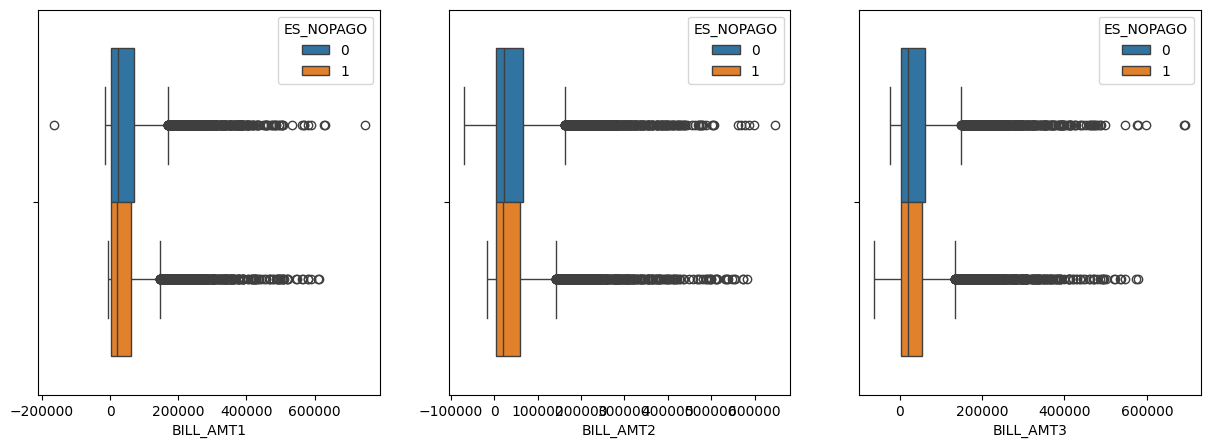

In [ ]:
fig,ax = plt.subplots(1,3,figsize=(15,5))

sns.boxplot(
    data = df_prep,
    x = 'BILL_AMT1',
    hue= 'ES_NOPAGO',
    ax = ax[0]
)
sns.boxplot(
    data = df_prep,
    x = 'BILL_AMT2',
    hue= 'ES_NOPAGO',
    ax = ax[1]
)
sns.boxplot(
    data = df_prep,
    x = 'BILL_AMT3',
    hue= 'ES_NOPAGO',
    ax = ax[2]
)
plt.show()

#### Determinando los niveles de outliers para BILL_AMT1

In [ ]:
Q1 = df_prep['BILL_AMT1'].quantile(0.25)
Q3 = df_prep['BILL_AMT1'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
lower_bound_e = Q1 - 3 * IQR
upper_bound_e = Q3 + 3 * IQR


print(f'Lower Limit : {lower_bound}')
print(f'Upper Limit : {upper_bound}')
print(f'Lower Limit extreme  : {lower_bound_e}')
print(f'Upper Limit extreme  : {upper_bound_e}')


Lower Limit : -90158.5
Upper Limit : 159803.5
Lower Limit extreme  : -183894.25
Upper Limit extreme  : 253539.25


In [ ]:
df_prep[df_prep['BILL_AMT1'] <= -159521.0]

,MONT_CREDIT,EST_CIVIL,NIV_EDUC,SEX,AGE,PAY_1,PAY_2,PAY_3,BILL_AMT1,BILL_AMT2,BILL_AMT3,PAY_AMT1,PAY_AMT2,PAY_AMT3,ES_NOPAGO
3270,300000.0,1,2,1,41,1,0,2,-165580.0,324392.0,296931.0,505000.0,331.0,1070.0,0


- Es fundamental realizar un tratamiento adecuado de los *outliers* dentro del dataset, ya que dependiendo del objetivo del análisis y del modelo seleccionado, estos pueden afectar significativamente el rendimiento.  
- En este caso particular, dado que se utilizará el modelo **KNeighborsClassifier**, el cual se basa en distancias para calcular similitudes, es necesario tratar los valores atípicos para evitar que distorsionen los resultados.  
- Como se identificó un caso claramente **atípico y único**, se decidió eliminarlo con el fin de mantener la eficiencia y robustez del modelo.


In [ ]:
df_prep = df_prep[df_prep['BILL_AMT1'] > -159521.0].copy()

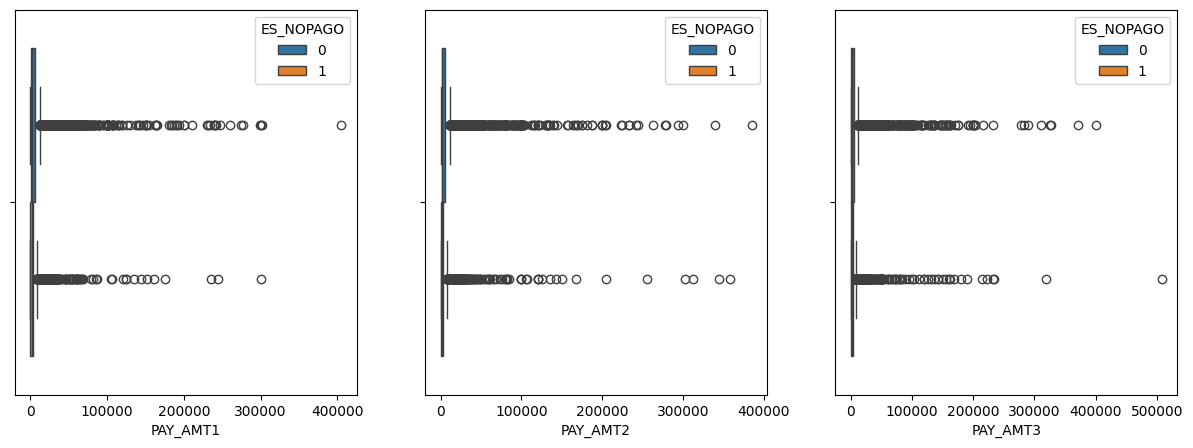

In [ ]:
fig,ax = plt.subplots(1,3,figsize=(15,5))

sns.boxplot(
    data = df_prep,
    x = 'PAY_AMT1',
    hue= 'ES_NOPAGO',
    ax = ax[0]
)
sns.boxplot(
    data = df_prep,
    x = 'PAY_AMT2',
    hue= 'ES_NOPAGO',
    ax = ax[1]
)
sns.boxplot(
    data = df_prep,
    x = 'PAY_AMT3',
    hue= 'ES_NOPAGO',
    ax = ax[2]
)
plt.show()

* Verificando otras variables, donde tambien encuentro outliers, sin embargo estos no son tan fuertes como BILL_AMT1, por lo que removerlo por ahora no es problema, tampoco hare tratamiento ya que es el comportamiento de un cliente y se debe evaluar el modelo de negocio.
* A menos que lo requiera un tratamiento, lo vere mas adelante, evaluando las metricas del modelo

---
# Analisis Exploratorio
---

## Analisis Univariado

In [ ]:
df_bi = df_prep.copy()

In [ ]:
df_bi[['EST_CIVIL',	'NIV_EDUC',	'SEX', 'PAY_1',	'PAY_2',	'PAY_3', 'ES_NOPAGO']] = df_bi[['EST_CIVIL',	'NIV_EDUC',	'SEX', 'PAY_1',	'PAY_2',	'PAY_3','ES_NOPAGO']].astype('object')

In [ ]:
## ==> Medidas de tendencia Central
# Numericas
df_bi[[
    'MONT_CREDIT','AGE','BILL_AMT1',	'BILL_AMT2',	'BILL_AMT3',	'PAY_AMT1',	'PAY_AMT2',	'PAY_AMT3'
]].describe()

,MONT_CREDIT,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,PAY_AMT1,PAY_AMT2,PAY_AMT3
count,16585.000000,16585.000000,16585.000000,16585.000000,16585.000000,16585.000000,16585.000000,16585.000000
mean,157785.709979,43.389991,50852.904311,48914.053241,46565.163461,5157.042991,4985.718842,4841.544769
std,124971.298782,8.771726,73393.374007,70766.453894,68200.193865,14540.524135,14883.293013,15663.090485
min,0.000000,20.000000,-14386.000000,-69777.000000,-61506.000000,0.000000,0.000000,0.000000
25%,50000.000000,37.000000,3578.000000,3079.000000,2632.000000,598.000000,498.000000,316.000000
50%,120000.000000,42.000000,22109.000000,21121.000000,20023.000000,2000.000000,2000.000000,1653.000000
75%,230000.000000,49.000000,66072.000000,62938.000000,59271.000000,5000.000000,4700.000000,4051.000000
max,800000.000000,72.000000,746814.000000,646770.000000,693131.000000,405016.000000,384986.000000,508229.000000


* Comprobamos aun en mayor medida que las variables __MONT_CREDIT__, __AGE__, __BILL_AMT__, __PAY_AMT__ presentan una alta disperson y valores máximos muy elevados respecto a la media (outliers - atipicos) .

In [ ]:
# Categoricas
df_bi[['EST_CIVIL',	'NIV_EDUC',	'SEX', 'PAY_1',	'PAY_2',	'PAY_3']].describe()

,EST_CIVIL,NIV_EDUC,SEX,PAY_1,PAY_2,PAY_3
count,16585,16585,16585,16585,16585,16585
unique,3,4,2,5,5,5
top,1,2,2,0,0,0
freq,8865,6921,9774,11708,13247,13495


| Variable   | Tipo      | Descripción |
|------------|-----------|-------------|
| **EST_CIVIL** | Categórica nominal | Estado civil (1=casado, 2=soltero, 3=otros). |
| **NIV_EDUC**  | Categórica ordinal | Nivel educativo (1=posgrado, 2=universidad, 3=escuela secundaria, 4=otros, 5=desconocido, 6=desconocido). |
| **SEX**       | Categórica nominal | Género (1=masculino, 2=femenino). |
| **PAY_1**     | Categórica ordinal | Estado de pago en septiembre de 2015 (-1=pago debido, 1=retraso de un mes, 2=retraso de dos meses, …, 9=retraso ≥9 meses). |
| **PAY_2**     | Categórica ordinal | Estado de pago en agosto de 2015 (escala igual a la anterior). |
| **PAY_3**     | Categórica ordinal | Estado de pago en julio de 2015 (escala igual a la anterior). |
| **ES_NOPAGO** | Categórica binaria | Pago de tarjeta (1=No pago, 0=Sí pago). |


Las variables categoricas tienen pocos valores unicos y estan concentradas en pocas categorias principales, lo que simplifica su tratamiento en el modelo y confirma su utilidad como predictores.

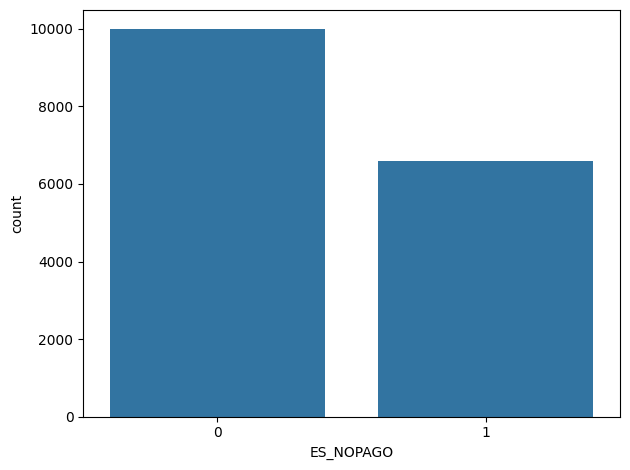

In [ ]:
## ==> Validar la distribucion de los datos, en caso de que exista un desbalanceo
sns.countplot(
    data = df_bi,
    x = 'ES_NOPAGO'
)
plt.tight_layout()
plt.show()

In [ ]:
df_bi.ES_NOPAGO.value_counts(normalize=True)

,proportion
ES_NOPAGO,
0,0.60199
1,0.39801


* Con la variable objetivo __ES_NOPAGO__ tenemos un leve desbalanceo de clases, _0.60 para los que si pagan y 0.40 para los que no pagan_, es importante determinar el % de desbalanceo, ya que al momento de presentar resultados del modelo, debemos establecer un umbral de corte para las predicciones.

## Analisis multivariado

### Variables Categoricas

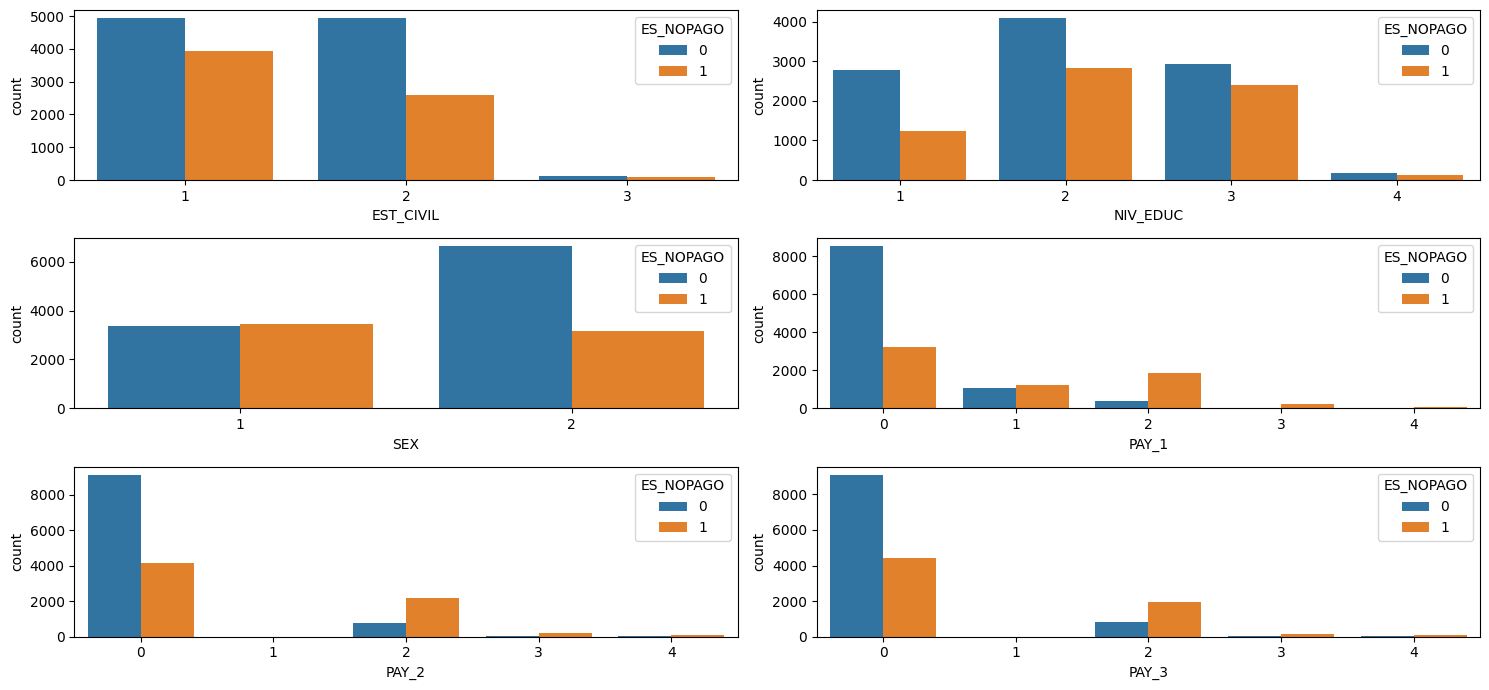

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols = 2, figsize=(15,7))
sns.countplot(
    data = df_bi,
    x = 'EST_CIVIL',
    hue='ES_NOPAGO',
    ax = ax[0][0]
)
sns.countplot(
    data = df_bi,
    x = 'NIV_EDUC',
    hue='ES_NOPAGO',
    ax = ax[0][1]
)
sns.countplot(
    data = df_bi,
    x = 'SEX',
    hue='ES_NOPAGO',
    ax = ax[1][0]
)
sns.countplot(
    data = df_bi,
    x = 'PAY_1',
    hue='ES_NOPAGO',
    ax = ax[1][1]
)
sns.countplot(
    data = df_bi,
    x = 'PAY_2',
    hue='ES_NOPAGO',
    ax = ax[2][0]
)
sns.countplot(
    data = df_bi,
    x = 'PAY_3',
    hue='ES_NOPAGO',
    ax = ax[2][1]
)
plt.tight_layout()
plt.show()

* Podemos determinar que a medida que el cliente se retrasa en el pago (PAY_1 - PAY_2 - PAY_3... la probabilidad de que un cliente no pague es mas alta)
* El genero masculino es el que mayormente no paga, a diferencia del genero femenino que si paga.
* El cliente que tenga como educacion __postgrado__ aumentan las probabilidades de que pague y no caiga en morosidad
* En cuanto al estado civil, no se observa un patron claro que diferencia entre quienes pagan y quienes no.
 __Conclusion :__ Podemos inferir que estas variables categoricas aportan un valor significativo para el modelo a usar, pues se verifica que existe segmentacion significativa para clientes que pagaron y no pagaron  

### Variables Numericas

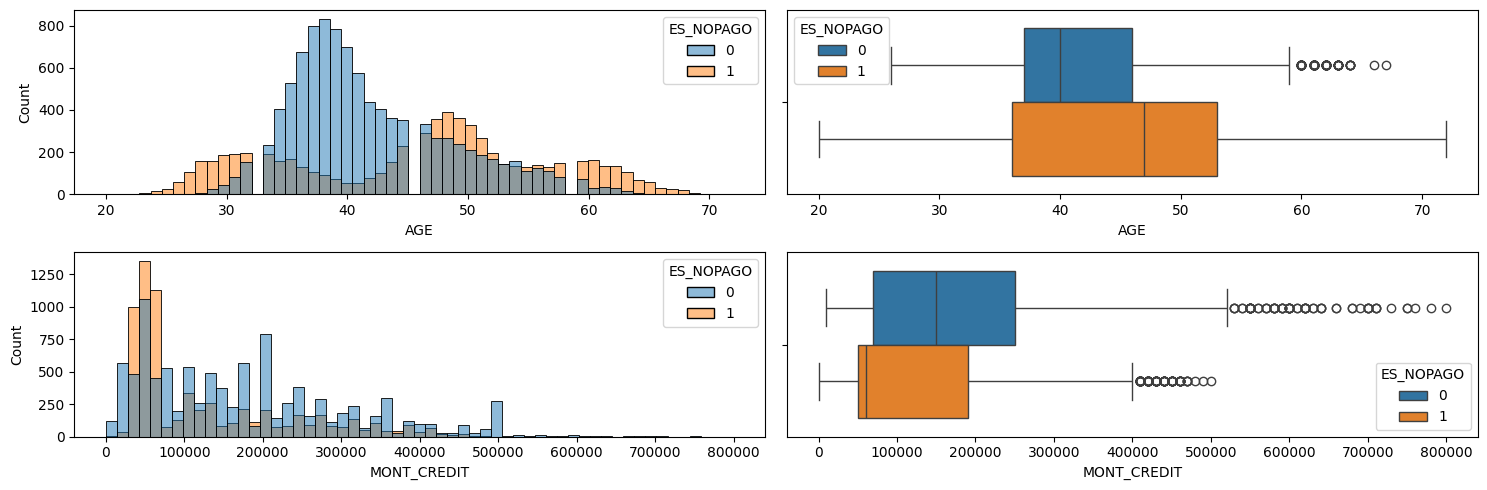

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(15,5))
sns.histplot(
    data = df_bi,
    x = 'AGE',
    hue = 'ES_NOPAGO',
    ax = ax[0][0]
)
sns.boxplot(
    data = df_bi,
    x = 'AGE',
    hue = 'ES_NOPAGO',
    ax = ax[0][1]
)
sns.histplot(
    data = df_bi,
    x = 'MONT_CREDIT',
    hue = 'ES_NOPAGO',
    ax = ax[1][0]
)
sns.boxplot(
    data = df_bi,
    x = 'MONT_CREDIT',
    hue = 'ES_NOPAGO',
    ax = ax[1][1]
)
plt.tight_layout()
plt.show()

* La mayoría de clientes se concentra entre los 30 y 50 años, destacando un grupo entre 35 y 45 años que presenta mayor probabilidad de pago.

* En cuanto al monto de crédito, se observa que clientes con créditos menores a 100.000 son más propensos a caer en impago, mientras que los de montos más altos muestran mayor cumplimiento.

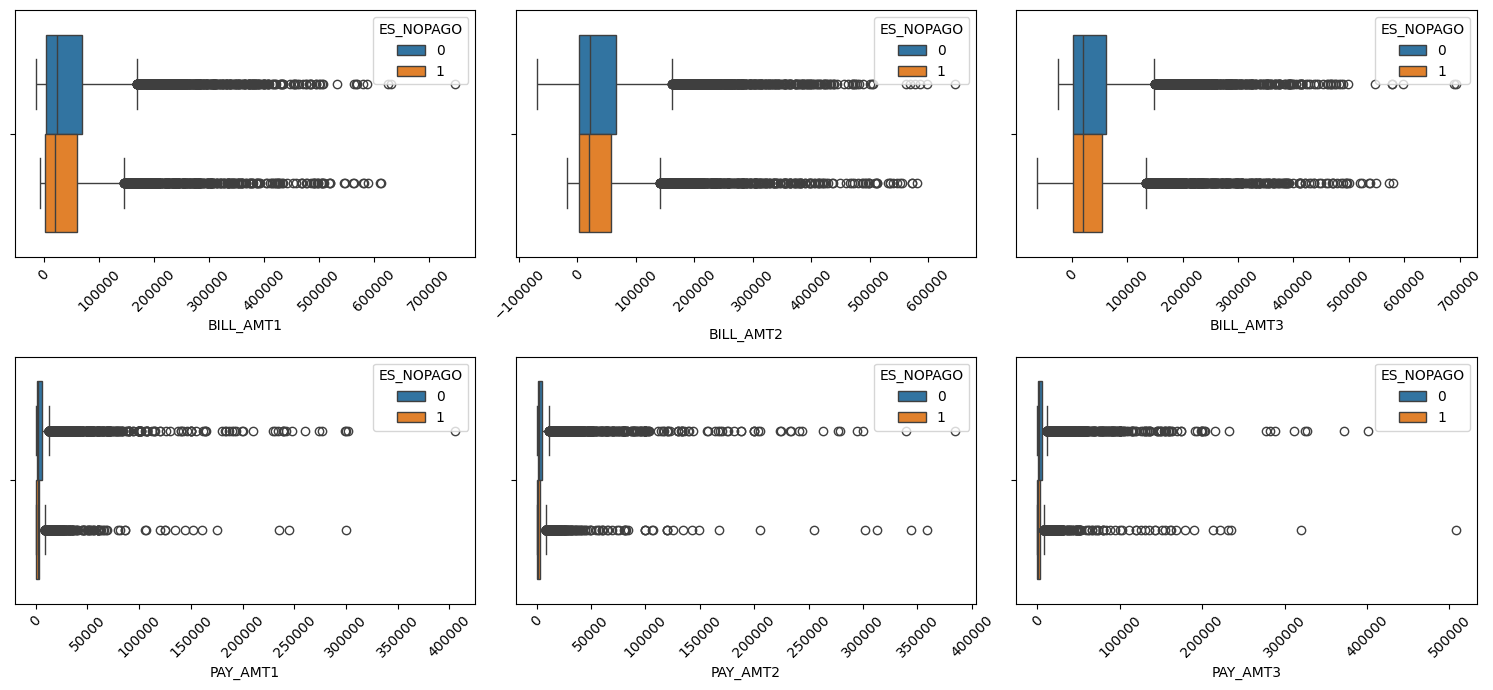

In [ ]:
fig, ax = plt.subplots(2,3, figsize=(15,7))
sns.boxplot(data = df_bi, x = 'BILL_AMT1', hue = 'ES_NOPAGO',  ax = ax[0][0])
sns.boxplot( data = df_bi, x = 'BILL_AMT2', hue = 'ES_NOPAGO', ax = ax[0][1])
sns.boxplot( data = df_bi, x = 'BILL_AMT3', hue = 'ES_NOPAGO', ax = ax[0][2])
sns.boxplot( data = df_bi, x = 'PAY_AMT1', hue = 'ES_NOPAGO',  ax = ax[1][0])
sns.boxplot( data = df_bi, x = 'PAY_AMT2', hue = 'ES_NOPAGO',  ax = ax[1][1])
sns.boxplot( data = df_bi, x = 'PAY_AMT3', hue = 'ES_NOPAGO',  ax = ax[1][2])
for axes in ax.flat:
  axes.tick_params(axis = 'x', rotation = 45)
plt.tight_layout()
plt.show()

* Se observan outliers muy altos tanto en facturación como en pagos, lo que indica clientes con montos extraordinarios que no representan a la mayoría.

* La mayoría de clientes se concentra en valores bajos, y en ese rango se distingue que quienes tienen facturas más bajas y pagos reducidos tienden a presentar mayor morosidad.

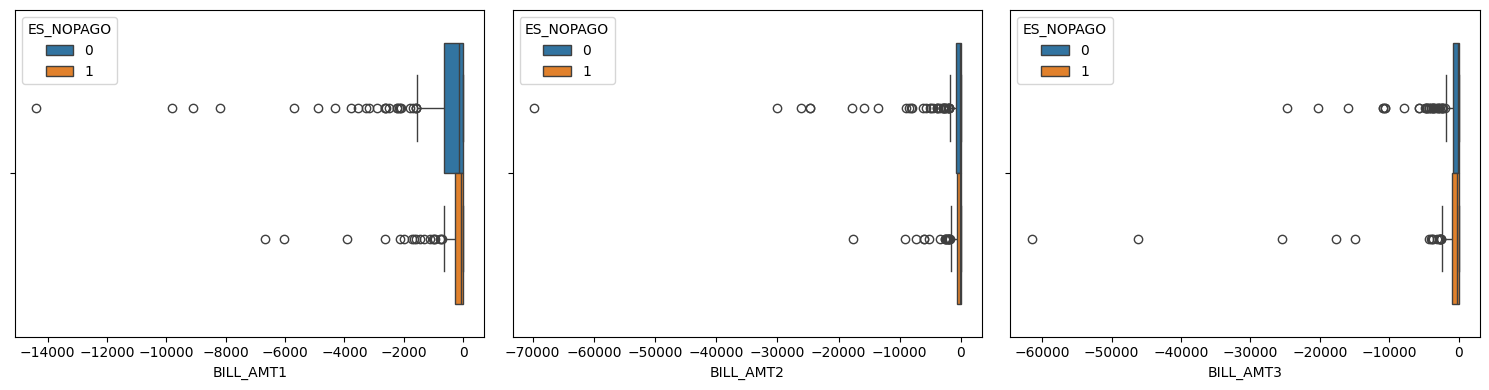

In [ ]:
## ==> Validando valores negativos, SALDOS A FAVOR DEL CLIENTE
fig, ax = plt.subplots(1,3, figsize=(15,4))
sns.boxplot(data = df_bi.query("BILL_AMT1 < 0"), x = 'BILL_AMT1', hue = 'ES_NOPAGO', ax = ax[0])
sns.boxplot(data = df_bi.query("BILL_AMT2 < 0"), x = 'BILL_AMT2', hue = 'ES_NOPAGO', ax = ax[1])
sns.boxplot(data = df_bi.query("BILL_AMT3 < 0"), x = 'BILL_AMT3', hue = 'ES_NOPAGO', ax = ax[2])
plt.tight_layout()
plt.show()

* Algunos importes de estados son negativos, esto conlleva a que el cliente en un mes determinado pago de mas, por lo que su cuenta para ellos saldra favorable, por ejemplo si tiene : -5000 esto es un saldo a su favor. Por lo que esto no es un error, sino parte de la naturaleza de un estado de cuenta
---

1.-__Realizar un análisis exploratorio de los campos que consideren necesarios para entender el comportamiento de los que pagan o no su tarjeta. Reportar los resultados obtenidos__

- **Distribución de la variable objetivo (ES_NOPAGO):**  
  Existe un leve desbalance, con aproximadamente **60% de clientes que sí pagan** y **40% que no pagan**.  

- **Variables categóricas:**  
  - Los **retrasos en los pagos (PAY_1, PAY_2, PAY_3)** muestran una relación clara con el impago:  
    a mayor retraso, mayor probabilidad de no pago.  
  - El **género masculino** se asocia con mayor morosidad, mientras que las mujeres presentan un mejor comportamiento de pago.  
  - Los clientes con **educación de posgrado** tienen mayor probabilidad de cumplir con sus pagos.  
  - El **estado civil** no presenta un patrón claro de diferenciación entre pagadores y no pagadores.  

- **Variables numéricas:**  
  - La **edad** se concentra entre **30 y 50 años**, destacando un grupo entre **35 y 45 años** con mayor cumplimiento.  
  - En cuanto al **monto de crédito (MONT_CREDIT)**, los clientes con créditos menores a **100.000** son más propensos a caer en impago, mientras que montos más altos muestran mayor cumplimiento.  
  - Tanto **facturación (BILL_AMT)** como **pagos realizados (PAY_AMT)** presentan **alta dispersión y outliers extremos**.  
  - Se identifican **valores negativos en facturación**, los cuales no son errores, sino **saldos a favor del cliente**.  

---

✅ **Conclusión general:**  
Los principales factores asociados al impago son los **retrasos en pagos recientes, montos de crédito bajos y género masculino**.  
Variables como **edad** y **educación** también aportan segmentación, mientras que se recomienda **tratar outliers en facturación y pagos** para mejorar la robustez de los modelos predictivos.

### Correlaciones

In [ ]:
num_var = ['MONT_CREDIT','AGE','BILL_AMT1','BILL_AMT2','BILL_AMT3',
            'PAY_AMT1','PAY_AMT2','PAY_AMT3','ES_NOPAGO']

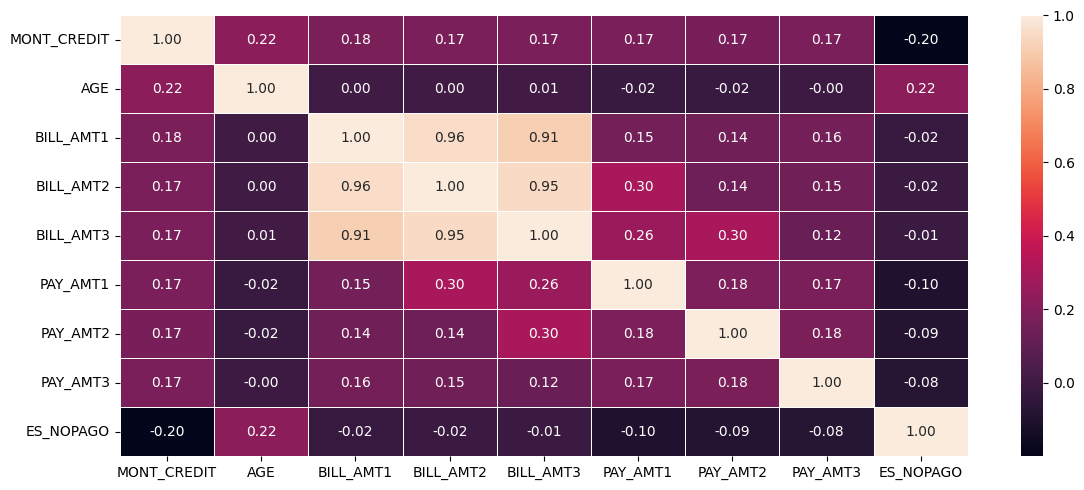

In [ ]:
plt.figure(figsize=(12,5))
correlacion = df_bi[num_var].corr()
sns.heatmap(data = correlacion, annot=True, fmt= ".2f", linewidths=.5)
plt.tight_layout()
plt.show()

* Se observa una alta correlacion level, entre variable Edad y Monto de credito contra la variable objetivo ES_NOPAGO, de ahi el resto presentan poca correlacion

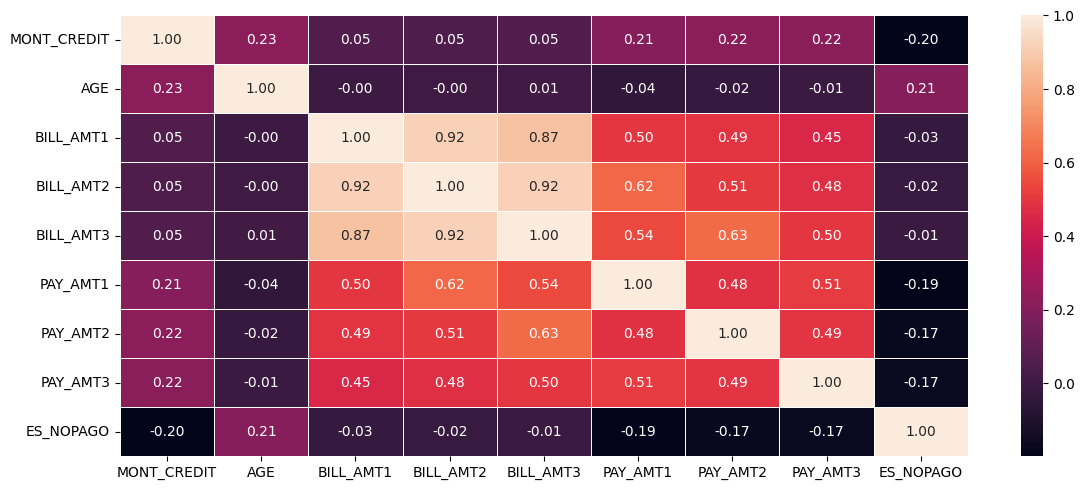

In [ ]:
plt.figure(figsize=(12,5))
correlacion = df_bi[num_var].corr(method = "spearman")
sns.heatmap(data = correlacion, annot=True, fmt= ".2f", linewidths=.5)
plt.tight_layout()
plt.show()

In [ ]:
cat_var = [
    'EST_CIVIL','NIV_EDUC','SEX','PAY_1','PAY_2','PAY_3'
]

In [ ]:
## ==> Chi Cuadrado
for column in cat_var:
    contingency_table = pd.crosstab(df_bi[column], df_bi['ES_NOPAGO'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    print(f'Chi- cuadrado: {chi2}')
    print(f'p-valor: {p_value}')
    print(f'Grados de libertad: {dof}')
    if p_value > 0.05 :
        print('Variable NO SIGNIFICATIVA --> Debe ser eliminada')
    else :
        print('Variable significativa')
    print('******')

Chi- cuadrado: 165.85245521938398
p-valor: 9.673796429130993e-37
Grados de libertad: 2
Variable significativa
******
Chi- cuadrado: 206.11897804657482
p-valor: 2.0087391627451616e-44
Grados de libertad: 3
Variable significativa
******
Chi- cuadrado: 565.7859710320813
p-valor: 4.634332211385362e-125
Grados de libertad: 1
Variable significativa
******
Chi- cuadrado: 3038.5131885638702
p-valor: 0.0
Grados de libertad: 4
Variable significativa
******
Chi- cuadrado: 2076.359015871566
p-valor: 0.0
Grados de libertad: 4
Variable significativa
******
Chi- cuadrado: 1572.8362330327461
p-valor: 0.0
Grados de libertad: 4
Variable significativa
******


* La tecnica-chi cuadrado se usa para este tipos de variables ordinales y nominales, dandonos de resultados que todas nuestras variables son altamente significativas para el modelo

In [ ]:
## == > Volviendo a poner como INT estas variables
df_bi[['EST_CIVIL',	'NIV_EDUC',	'SEX', 'PAY_1',	'PAY_2',	'PAY_3', 'ES_NOPAGO']] = df_bi[['EST_CIVIL',	'NIV_EDUC',	'SEX', 'PAY_1',	'PAY_2',	'PAY_3','ES_NOPAGO']].astype(int)

__2.-Análisis multivariado que permita comprender la relación que existe entre las variables. ¿Cree conveniente excluir variables dado los resultados de este análisis? Justifique su respuesta__

Al revisar las variables numéricas continuas, se observa multicolinealidad entre `BILL_AMT1`, `BILL_AMT2` y `BILL_AMT3`, lo cual es esperable ya que todas representan montos de facturación en meses consecutivos.  
Mantener las tres puede generar **redundancia en modelos lineales** como *Logistic Regression*, por lo que sería conveniente conservar solo una de ellas o aplicar alguna técnica de **reducción de dimensionalidad** (ej. *PCA*).  

En el caso de las **variables categóricas** (`EST_CIVIL`, `NIV_EDUC`, `SEX`, `PAY_1`, `PAY_2`, `PAY_3`), todas muestran relación con la variable objetivo (`ES_NOPAGO`), por lo que **no se recomienda eliminarlas**, ya que aportan información valiosa al modelo.  

---

__Conclusión__

- En modelos **sensibles a la multicolinealidad** (ej. *Logistic Regression*), es recomendable reducir o eliminar variables numéricas altamente correlacionadas.  
- En modelos **robustos** como *Random Forest* o *KNN*, no es estrictamente necesario eliminarlas, ya que estos algoritmos manejan mejor la redundancia.  

---
# Ingenieria de caracteristicas
---

### Creacion de nuevas variables

In [ ]:
df_feature = df_bi.copy()

In [ ]:
# Utilización del crédito (riesgo de sobreuso)
df_feature['CREDIT_UTIL1'] = np.where(
    df_feature['MONT_CREDIT'] == 0,
    0,  # puedes poner 0 o np.nan y luego imputar
    df_feature['BILL_AMT1'] / df_feature['MONT_CREDIT']
)

# Mora histórica (intensidad y presencia)
df_feature['DEMORA_SUM'] = df_feature[['PAY_1','PAY_2','PAY_3']].sum(axis=1)
df_feature['DEMORA_MAX'] = df_feature[['PAY_1','PAY_2','PAY_3']].max(axis=1)

df_feature['MESES_AL_DIA'] = (df_feature[['PAY_1','PAY_2','PAY_3']] == 0).sum(axis=1)

# Diferencia entre el monto del último mes (BILL_AMT1) y el menor de los 3 meses
df_feature['VARIACION_TOTAL_CUENTA'] = df_feature['BILL_AMT1'] - df_feature[['BILL_AMT1','BILL_AMT2','BILL_AMT3']].min(axis=1)


Se crearon nuevas variables para capturar mejor el comportamiento del cliente:  

- **CREDIT_UTIL1**: relación entre saldo y crédito total (riesgo de sobreuso).  
- **DEMORA_SUM, DEMORA_MAX y MESES_AL_DIA**: resumen de intensidad y frecuencia de atrasos.  
- **VARIACION_TOTAL_CUENTA**: diferencia entre el último saldo y el mínimo de los 3 meses previos.  


In [ ]:
df_feature.head()

,MONT_CREDIT,EST_CIVIL,NIV_EDUC,SEX,AGE,PAY_1,PAY_2,PAY_3,BILL_AMT1,BILL_AMT2,BILL_AMT3,PAY_AMT1,PAY_AMT2,PAY_AMT3,ES_NOPAGO,CREDIT_UTIL1,DEMORA_SUM,DEMORA_MAX,MESES_AL_DIA,VARIACION_TOTAL_CUENTA
0,30000.0,1,1,2,40,0,0,0,24607.0,24430.0,23881.0,1700.0,1600.0,1287.0,0,0.820233,0,0,3,726.0
1,20000.0,1,1,2,41,1,2,0,17040.0,16474.0,17203.0,0.0,1300.0,1500.0,0,0.852000,3,2,1,566.0
2,20000.0,1,1,2,36,0,0,0,17332.0,18600.0,17947.0,1580.0,1367.0,1178.0,0,0.866600,0,0,3,0.0
3,20000.0,1,1,2,35,0,0,0,2003.0,2948.0,3372.0,1086.0,1000.0,0.0,0,0.100150,0,0,3,0.0
4,170000.0,1,1,2,38,0,0,0,171465.0,145196.0,110163.0,18500.0,13998.0,3760.0,0,1.008618,0,0,3,61302.0


In [ ]:
num_var = ['MONT_CREDIT','AGE','BILL_AMT1','BILL_AMT2','BILL_AMT3',
            'PAY_AMT1','PAY_AMT2','PAY_AMT3',
           'CREDIT_UTIL1','VARIACION_TOTAL_CUENTA','ES_NOPAGO']

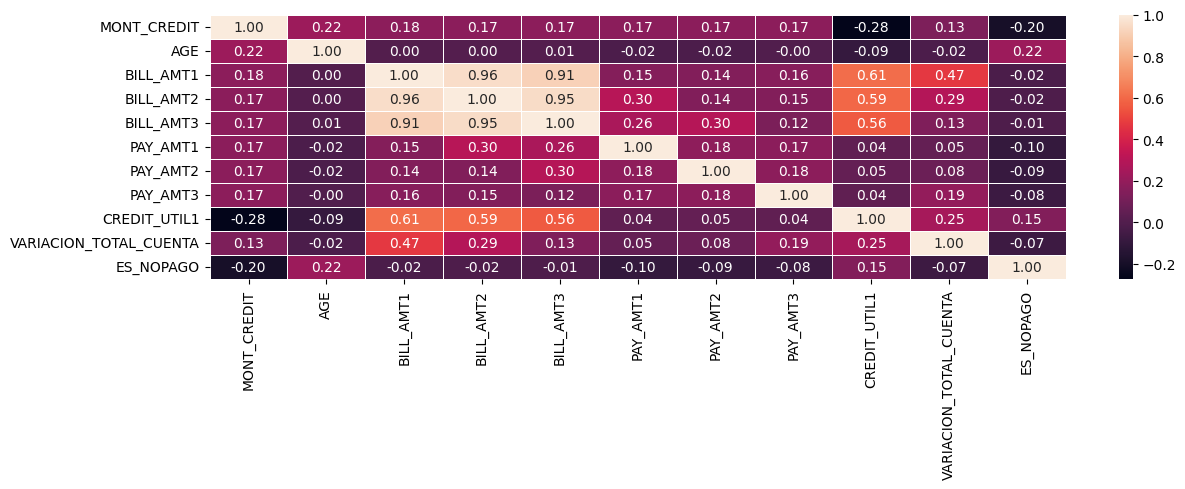

In [ ]:
plt.figure(figsize=(13,5))
correlacion = df_feature[num_var].corr(method='pearson')
sns.heatmap(data = correlacion, annot=True, fmt= ".2f", linewidths=.5)
plt.tight_layout()
plt.show()


- Ambas variables no tienen correlación alta con la variable objetivo `ES_NOPAGO` (≤ 0.15), pero sí aportan nuevas perspectivas útiles para el modelo, especialmente en el análisis del riesgo de sobreuso y la variación de deuda.  


In [ ]:
cat_var = [
    'DEMORA_SUM',	'DEMORA_MAX','MESES_AL_DIA'
]
## ==> Chi Cuadrado
for column in cat_var:
    contingency_table = pd.crosstab(df_feature[column], df_feature['ES_NOPAGO'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    print(f'Chi- cuadrado: {chi2}')
    print(f'p-valor: {p_value}')
    print(f'Grados de libertad: {dof}')
    if p_value > 0.05 :
        print('Variable NO SIGNIFICATIVA --> Debe ser eliminada')
    else :
        print('Variable significativa')
    print('******')

Chi- cuadrado: 3217.8409350725933
p-valor: 0.0
Grados de libertad: 12
Variable significativa
******
Chi- cuadrado: 3023.8601588424144
p-valor: 0.0
Grados de libertad: 4
Variable significativa
******
Chi- cuadrado: 2987.9763230317994
p-valor: 0.0
Grados de libertad: 3
Variable significativa
******


Las tres variables aportan información relevante para explicar la probabilidad de no pago (`ES_NOPAGO`). Ninguna debe ser eliminada, ya que todas presentan asociación estadísticamente significativa.

In [ ]:
target = 'ES_NOPAGO'
num_vars = [c for c in df_feature.columns if c not in [target]]

corrs = {}
for col in num_vars:
    r, p = pointbiserialr(df_feature[target], df_feature[col])
    corrs[col] = {'point_biserial_r': r, 'p_value': p}

pd.DataFrame(corrs).T.sort_values('point_biserial_r', ascending=False)

,point_biserial_r,p_value
DEMORA_MAX,0.418482,0.000000e+00
PAY_1,0.415644,0.000000e+00
DEMORA_SUM,0.407662,0.000000e+00
PAY_2,0.345144,0.000000e+00
PAY_3,0.303109,0.000000e+00
AGE,0.221866,4.769119e-184
CREDIT_UTIL1,0.146765,1.630756e-80
NIV_EDUC,0.103793,5.892995e-41
BILL_AMT3,-0.013641,7.897210e-02
BILL_AMT2,-0.015855,4.116922e-02


* Se utiliza **point biserial correlation** porque la variable objetivo `ES_NOPAGO` es **binaria**, y permite medir de forma adecuada la relación entre esta y las variables **numéricas**.
---

__3.	Actividad adicional: Si desea crear variables a partir de las facilitadas, hágalo, pero justifique la razón de ser y probar en el siguiente paso si aporta a la predicción (2 puntos adicionales al general)__

**Resultados del análisis:**

- En el **point biserial**, las variables con mayor aporte son:
  - `DEMORA_MAX (0.418)`, `PAY_1 (0.415)` y `DEMORA_SUM (0.407)`.
  - Esto confirma que las variables relacionadas con retrasos capturan la señal más fuerte de morosidad.
- **CREDIT_UTIL1** ahora sí devuelve un valor válido (**0.1467, p < 0.001**) y aunque no es tan alto como las variables de demora, refleja adecuadamente el **riesgo de sobreuso del crédito**.
- `VARIACION_TOTAL_CUENTA` mantiene una correlación baja y negativa (-0.07), lo que sugiere poco poder predictivo directo, aunque puede aportar en interacciones o modelos no lineales.
- La similitud entre `DEMORA_MAX`, `PAY_1` y `DEMORA_SUM` se explica porque todas condensan el mismo patrón de atrasos, aunque desde ángulos distintos (máximo atraso, atraso puntual o suma total).

**Conclusión:**

- Las variables de mora (`DEMORA_MAX`, `DEMORA_SUM`, `PAY_1`) son las más influyentes y deben mantenerse en la predicción.  
- `CREDIT_UTIL1` pasa a ser una variable útil, ya que refleja el nivel de utilización del crédito y tiene señal estadísticamente significativa.  
- `VARIACION_TOTAL_CUENTA` puede mantenerse en pruebas, pero con menor prioridad debido a su baja correlación.  
- En conjunto, estas variables adicionales enriquecen la representación del comportamiento del cliente y pueden mejorar el rendimiento predictivo.

---
# Prediccion
---

__4.- Crear tres modelos que le permitan detectar la probabilidad de que se cumpla el evento tomando en cuenta que el 70% de la base sea para construir el modelo y el 30% para probar sus resultados, colocar la semilla en 876. (5 puntos)__

Los modelos utilizados para el análisis de riesgo crediticio fueron:  
- **RandomForestClassifier**: un algoritmo de ensamblado basado en múltiples árboles de decisión, robusto frente a outliers y capaz de capturar relaciones no lineales.  
- **KNeighborsClassifier (KNN)**: un modelo basado en la similitud entre instancias, útil para evaluar cómo las características de un cliente se relacionan con sus vecinos más cercanos.  
- **Logistic Regression**: un modelo lineal ampliamente utilizado en riesgo crediticio, que permite interpretar directamente el peso de cada variable sobre la probabilidad de incumplimiento.  

A continuación, se presenta el desarrollo y análisis paso a paso de cada modelo, incluyendo la optimización de hiperparámetros, métricas de desempeño, ajuste de umbrales y la interpretación de variables más relevantes.

## RandomForestClassifier

In [ ]:
df_ml_rf = df_feature.copy()
df_ml_rf.head()

,MONT_CREDIT,EST_CIVIL,NIV_EDUC,SEX,AGE,PAY_1,PAY_2,PAY_3,BILL_AMT1,BILL_AMT2,BILL_AMT3,PAY_AMT1,PAY_AMT2,PAY_AMT3,ES_NOPAGO,CREDIT_UTIL1,DEMORA_SUM,DEMORA_MAX,MESES_AL_DIA,VARIACION_TOTAL_CUENTA
0,30000.0,1,1,2,40,0,0,0,24607.0,24430.0,23881.0,1700.0,1600.0,1287.0,0,0.820233,0,0,3,726.0
1,20000.0,1,1,2,41,1,2,0,17040.0,16474.0,17203.0,0.0,1300.0,1500.0,0,0.852000,3,2,1,566.0
2,20000.0,1,1,2,36,0,0,0,17332.0,18600.0,17947.0,1580.0,1367.0,1178.0,0,0.866600,0,0,3,0.0
3,20000.0,1,1,2,35,0,0,0,2003.0,2948.0,3372.0,1086.0,1000.0,0.0,0,0.100150,0,0,3,0.0
4,170000.0,1,1,2,38,0,0,0,171465.0,145196.0,110163.0,18500.0,13998.0,3760.0,0,1.008618,0,0,3,61302.0


In [ ]:
nominal = ['EST_CIVIL', 'SEX']                 # sin orden → One-Hot
ordinal = ['NIV_EDUC', 'PAY_1', 'PAY_2', 'PAY_3']  # con orden → numéricas

df_base = pd.get_dummies(
    df_ml_rf,
    columns=nominal,
    drop_first=False,
    dtype=int
)
rename_dict = {
    "EST_CIVIL_1": "Civil_Casado",
    "EST_CIVIL_2": "Civil_Soltero",
    "EST_CIVIL_3": "Civil_Otros",
    "SEX_1": "Sexo_Masculino",
    "SEX_2": "Sexo_Femenino"
}

df_base = df_base.rename(columns=rename_dict)
df_base.head()

,MONT_CREDIT,NIV_EDUC,AGE,PAY_1,PAY_2,PAY_3,BILL_AMT1,BILL_AMT2,BILL_AMT3,PAY_AMT1,PAY_AMT2,PAY_AMT3,ES_NOPAGO,CREDIT_UTIL1,DEMORA_SUM,DEMORA_MAX,MESES_AL_DIA,VARIACION_TOTAL_CUENTA,Civil_Casado,Civil_Soltero,Civil_Otros,Sexo_Masculino,Sexo_Femenino
0,30000.0,1,40,0,0,0,24607.0,24430.0,23881.0,1700.0,1600.0,1287.0,0,0.820233,0,0,3,726.0,1,0,0,0,1
1,20000.0,1,41,1,2,0,17040.0,16474.0,17203.0,0.0,1300.0,1500.0,0,0.852000,3,2,1,566.0,1,0,0,0,1
2,20000.0,1,36,0,0,0,17332.0,18600.0,17947.0,1580.0,1367.0,1178.0,0,0.866600,0,0,3,0.0,1,0,0,0,1
3,20000.0,1,35,0,0,0,2003.0,2948.0,3372.0,1086.0,1000.0,0.0,0,0.100150,0,0,3,0.0,1,0,0,0,1
4,170000.0,1,38,0,0,0,171465.0,145196.0,110163.0,18500.0,13998.0,3760.0,0,1.008618,0,0,3,61302.0,1,0,0,0,1


In [ ]:
df_ml_rf = df_base.copy()

In [ ]:
X = df_ml_rf.drop(columns=['ES_NOPAGO'])
y = df_ml_rf['ES_NOPAGO']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y , test_size = 0.3, random_state =SEED , stratify= y)

In [ ]:
x_train_ml = pd.concat([x_train, y_train], axis = 1)
x_train_ml.head()

,MONT_CREDIT,NIV_EDUC,AGE,PAY_1,PAY_2,PAY_3,BILL_AMT1,BILL_AMT2,BILL_AMT3,PAY_AMT1,PAY_AMT2,PAY_AMT3,CREDIT_UTIL1,DEMORA_SUM,DEMORA_MAX,MESES_AL_DIA,VARIACION_TOTAL_CUENTA,Civil_Casado,Civil_Soltero,Civil_Otros,Sexo_Masculino,Sexo_Femenino,ES_NOPAGO
2968,50000.0,2,40,0,0,0,50586.0,46993.0,33136.0,2000.0,2000.0,2000.0,1.011720,0,0,3,17450.0,1,0,0,0,1,0
9043,240000.0,2,56,0,0,0,27967.0,28707.0,27970.0,10016.0,2081.0,169267.0,0.116529,0,0,3,0.0,0,1,0,1,0,0
16238,300000.0,3,65,1,2,0,83367.0,81409.0,78790.0,0.0,2873.0,3101.0,0.277890,3,2,1,4577.0,0,1,0,0,1,1
1283,50000.0,1,36,0,0,0,2463.0,0.0,0.0,0.0,0.0,536.0,0.049260,0,0,3,2463.0,0,1,0,0,1,0
15414,280000.0,2,46,2,2,2,20801.0,23534.0,22875.0,3400.0,0.0,2000.0,0.074289,6,2,0,0.0,1,0,0,1,0,1


#### Encontrando los estimadores mas optimos

[np.float64(0.8574355431947275), np.float64(0.896633798348255), np.float64(0.9245598056444886), np.float64(0.9363347591190477), np.float64(0.9419371596917273), np.float64(0.9452687905123464), np.float64(0.9462633661704336), np.float64(0.946507101231779)]


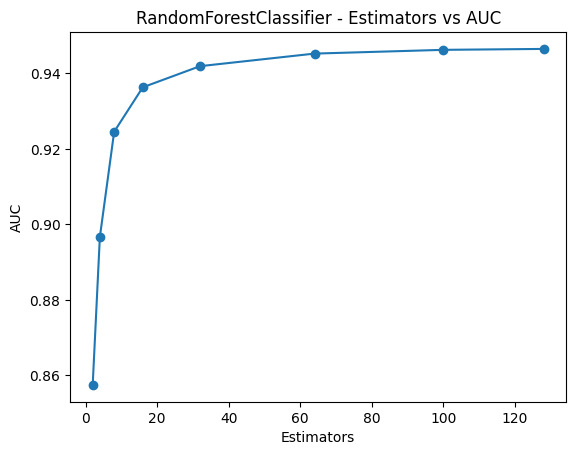

In [ ]:
kf = KFold(n_splits = 5, shuffle = True, random_state=SEED)
l_estimators = [2, 4, 8, 16, 32, 64, 100, 128]

total_scores = []
for estimator in l_estimators:
  fold_accuracy = []
  base_rf = RandomForestClassifier(n_estimators = estimator, random_state = SEED)
  for train_fold, test_fold in kf.split(x_train_ml):

    # Division train test aleatoria
    f_train = x_train_ml.iloc[train_fold]
    f_test = x_train_ml.iloc[test_fold]

    # Entrenamiento y ejecucion del modelo
    base_rf.fit(X = f_train.drop(columns=['ES_NOPAGO']), y = f_train['ES_NOPAGO'])
    #y_pred = base_rf.predict(X = f_test.drop(columns=['ES_NOPAGO']))
    y_pred_proba = base_rf.predict_proba(X = f_test.drop(columns=['ES_NOPAGO']))[:,1]

    # Evaluacion del modelo
    #accuracy = accuracy_score(f_test['ES_NOPAGO'], y_pred)
    auc = roc_auc_score(f_test['ES_NOPAGO'], y_pred_proba)
    fold_accuracy.append(auc)
  total_scores.append(sum(fold_accuracy) / len(fold_accuracy))

print(total_scores)
plt.plot(l_estimators, total_scores, marker = 'o')
plt.title('RandomForestClassifier - Estimators vs AUC')
plt.ylabel('AUC')
plt.xlabel('Estimators')
plt.show()

* Se realizó una validación cruzada de 5-FOLD probando distintas cantidades de estimadores.  
  El resultado muestra que el número óptimo de árboles esta entre **32 y 64**, ya que a partir de este punto el AUC se estabiliza y no mejora significativamente.  
  Por lo tanto, aumentar más estimadores no es conveniente porque puede incrementar el tiempo de cómputo y generar sobreajuste.  

* Adicionalmente, se utilizó la métrica **AUC**, porque es más robusta que la exactitud al evaluar modelos desbalanceados, en nuestro caso posee un leve desbalanceo.  
  El AUC mide la capacidad de discriminación entre clases (pago vs. no pago), lo que es clave en este tipo de problema.


#### Encontrando la profundidad mas optima

[np.float64(0.8086074727732493), np.float64(0.8469990248955156), np.float64(0.8655448181209063), np.float64(0.890896431502741), np.float64(0.9091904219689966), np.float64(0.9233923109182751), np.float64(0.9299470029302197), np.float64(0.9370996410305951), np.float64(0.940086015656141), np.float64(0.9427675809201024), np.float64(0.9438335516800012), np.float64(0.944013937946927), np.float64(0.9457285193877218), np.float64(0.9438032351575927), np.float64(0.9444842301720275), np.float64(0.9448994959691117), np.float64(0.9439014214749673), np.float64(0.9444385938454889), np.float64(0.9443080775416653)]


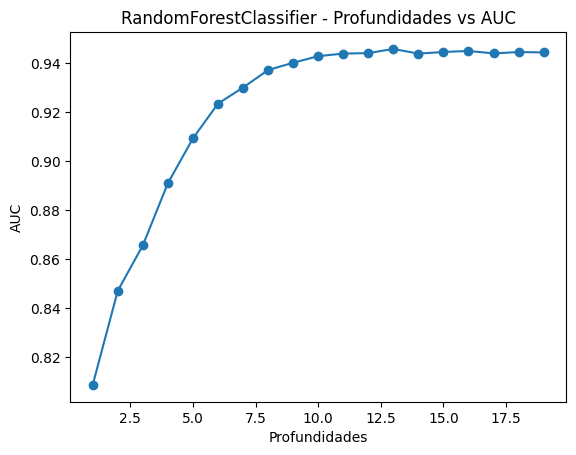

In [ ]:
kf = KFold(n_splits = 5, shuffle = True, random_state=SEED)
l_profundidades = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19]

total_scores = []
for profundidad in l_profundidades:
  fold_accuracy = []
  base_rf = RandomForestClassifier(n_estimators = 32, random_state = SEED, max_depth = profundidad)
  for train_fold, test_fold in kf.split(x_train_ml):
    # Division train test aleatoria
    f_train = x_train_ml.iloc[train_fold]
    f_test = x_train_ml.iloc[test_fold]

    # Entrenamiento y ejecucion del modelo
    base_rf.fit(X = f_train.drop(columns=['ES_NOPAGO']), y = f_train['ES_NOPAGO'])
    #y_pred = base_rf.predict(X = f_test.drop(columns=['ES_NOPAGO']))
    y_pred_proba = base_rf.predict_proba(X = f_test.drop(columns=['ES_NOPAGO']))[:,1]

    # Evaluacion del modelo
    #accuracy = accuracy_score(f_test['ES_NOPAGO'], y_pred)
    auc = roc_auc_score(f_test['ES_NOPAGO'], y_pred_proba)
    fold_accuracy.append(auc)
  total_scores.append(sum(fold_accuracy) / len(fold_accuracy))

print(total_scores)
plt.plot(l_profundidades, total_scores, marker = 'o')
plt.title('RandomForestClassifier - Profundidades vs AUC')
plt.ylabel('AUC')
plt.xlabel('Profundidades')
plt.show()

- Uno de los hiperparámetros más relevantes en un **Random Forest** es la **profundidad máxima de los árboles (max_depth)**, ya que controla el equilibrio entre sesgo y varianza.  
- Mediante **validación cruzada** se evaluaron distintas profundidades, tomando como referencia el mejor número de estimadores (32).  
- El resultado óptimo se obtuvo en un rango de **7 a 9 niveles de profundidad** sin embargo el mejor Score se obute con una profundidad de **13 niveles** luego de eso se ve que baja un poco su rendimiento.
- Se hara una optimización con RandomSearchCV probando estos niveles de profundidad, no es tan ideal darle un nivel de 13, existe una probabilidad de que se sobreajuste.


#### Optimización  - RandomizedSearchCV

In [ ]:
## ==> RandomizedSearchCV
rf = RandomForestClassifier(random_state = SEED, class_weight='balanced' )

params_rf = {
    "n_estimators" : [16, 32, 64, 100],
    "max_depth" : [7, 8, 9, 10,11,12,13],
    "min_samples_split": randint(2, 11),
    "min_samples_leaf": randint(1, 6),
    "max_features": ["sqrt", "log2", 0.3, 0.5],
    "min_impurity_decrease": uniform(0.0, 0.01),
    "ccp_alpha": uniform(0.0, 0.002)
}

rf_random = RandomizedSearchCV(
    estimator = rf,
    param_distributions = params_rf,
    n_iter = 50,
    cv = 5,
    scoring = "roc_auc",
    random_state = SEED,
    n_jobs = -1
)

rf_random.fit(x_train, y_train)
print(rf_random.best_params_)
rf_random.best_estimator_

{'ccp_alpha': np.float64(0.0014684829454918661), 'max_depth': 12, 'max_features': 0.5, 'min_impurity_decrease': np.float64(0.0007845563478008821), 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 16}


RandomForestClassifier(ccp_alpha=np.float64(0.0014684829454918661),
                       class_weight='balanced', max_depth=12, max_features=0.5,
                       min_impurity_decrease=np.float64(0.0007845563478008821),
                       min_samples_leaf=2, min_samples_split=5, n_estimators=16,
                       random_state=876)

In [ ]:
best_rf_random = rf_random.best_estimator_

* Utilizando la optimizacion de hiperparametros con RandomSearchCV, obtuvimos que nuestro mejor arbol tienen una cantidad de 16 estimadores y 12 de profundidad, parecido a lo que conseguimos a nuestra validacion cruzada

#### Predicciones

In [ ]:
y_proba = best_rf_random.predict_proba(x_test)[:,1]
y_predict = best_rf_random.predict(x_test)

x_proba = best_rf_random.predict_proba(x_train)[:,1]
x_predict = best_rf_random.predict(x_train)

Aqui conseguimos las predicciones tanto de x_train (para detectar sobreajuste) y x_test

#### AUC - SCORE

In [ ]:
print(f'roc_auc_score  (conjunto de test):  {roc_auc_score(y_test, y_proba):.4}')

roc_auc_score  (conjunto de test):  0.9355


EL resultado es muy bueno, con un 0.9355 de AUC nuestro modelo logra discriminar entre los que van a pagar y no van a pagar

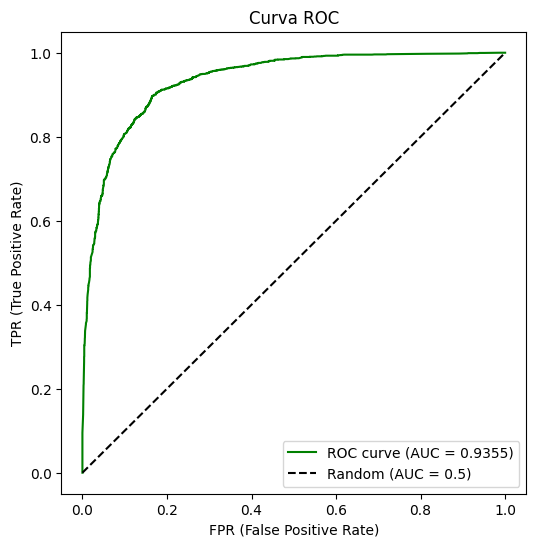

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color = 'green', label = f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1], color = 'black', linestyle = '--', label = 'Random (AUC = 0.5)')
plt.xlabel("FPR (False Positive Rate)")
plt.ylabel("TPR (True Positive Rate)")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.show()

#### Verificando si existe Overfiting


In [ ]:
## ==> Check List Rapido
print(f'roc_auc_score  (conjunto de train):  {roc_auc_score(y_train, x_proba):.4}')

roc_auc_score  (conjunto de train):  0.9448


In [ ]:
## ==> Validacion cruzada con los hiperparametros obtenido
folds = KFold(n_splits = 5, shuffle = True, random_state = SEED)
scores = cross_val_score(best_rf_random, x_train, y_train, cv = folds, scoring = 'roc_auc')
print(f"AUC por fold {scores}")
print(f"AUC promedio: {scores.mean():.4f}")

AUC por fold [0.93699992 0.94182472 0.93702532 0.94131578 0.93868492]
AUC promedio: 0.9392


- Nuestro conjunto de Test fue un **AUC de 0.9355**
- En el conjunto de Entrenamiento se obtuvo un **AUC = 0.9448**, valor consistente con el de test, lo que indica buen ajuste.  
- Con validación cruzada (5-Fold), el promedio fue **0.9392**, muy cercano al resultado individual, mostrando estabilidad entre los folds.  
- La cercanía entre los valores de entrenamiento, validación y test permite concluir que el modelo **no presenta sobreajuste** y generaliza de forma adecuada.

#### Metricas de Bondad

In [ ]:
## ==> Sin establecer UMBRAL DE CORTE
print(f"Accuracy: {accuracy_score(y_test, y_predict):.4f}" )
print(f"Precision: {precision_score(y_test, y_predict):.4f}" )
print(f"Recall: {recall_score(y_test, y_predict):.4f}" )
print(f"F1-score: {f1_score(y_test, y_predict):.4f}" )

Accuracy: 0.8563
Precision: 0.7876
Recall: 0.8747
F1-score: 0.8289


In [ ]:
print("Confusion matrix:\n", confusion_matrix(y_test, y_predict))

Confusion matrix:
 [[2529  467]
 [ 248 1732]]


In [ ]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.91      0.84      0.88      2996
           1       0.79      0.87      0.83      1980

    accuracy                           0.86      4976
   macro avg       0.85      0.86      0.85      4976
weighted avg       0.86      0.86      0.86      4976



- El modelo alcanza un **Accuracy de 0.8563 y F1-score de 0.8289**, mostrando buen equilibrio entre precisión y recall.  
- Esto indica que el modelo predice de forma consistente sin favorecer en exceso a ninguna clase.  


#### Metricas de Bondad con umbral de corte

In [ ]:
## ==>  Metodo clasico (SKLEARN)
umbrales = np.linspace(0,1,101)
mejor_umbral = None
mejor_f1 = -1
for umbral in umbrales:
  y_pred = (y_proba >= umbral).astype(int)
  f1 = f1_score(y_test, y_pred)
  if f1 > mejor_f1:
    mejor_f1 = f1
    mejor_umbral = umbral
print(f"Mejor umbral: {mejor_umbral:.4}")
print(f"Mejor f1: {mejor_f1:.4}" )

Mejor umbral: 0.47
Mejor f1: 0.8353


In [ ]:
y_pred_opt = (y_proba >= 0.47).astype(int)

## ==> Metricas
print(f"Accuracy: {accuracy_score(y_test, y_pred_opt):.4f}" )
print(f"Precision: {precision_score(y_test, y_pred_opt):.4f}" )
print(f"Recall: {recall_score(y_test, y_pred_opt):.4f}" )
print(f"F1-score: {f1_score(y_test, y_pred_opt):.4f}" )


Accuracy: 0.8595
Precision: 0.7828
Recall: 0.8955
F1-score: 0.8353


In [ ]:
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_opt))

Confusion matrix:
 [[2504  492]
 [ 207 1773]]


In [ ]:
print(classification_report(y_test, y_pred_opt))

              precision    recall  f1-score   support

           0       0.92      0.84      0.88      2996
           1       0.78      0.90      0.84      1980

    accuracy                           0.86      4976
   macro avg       0.85      0.87      0.86      4976
weighted avg       0.87      0.86      0.86      4976



**Conclusión:**  

- **Sin umbral:** El modelo logra un buen equilibrio entre precisión (**0.7876**) y recall (**0.8747**), con un F1-score de **0.8289**.  
- **Con umbral 0.47:** El recall mejora de **0.8747 → 0.8955**, aumentando la capacidad de detectar morosos.  
  - La precisión baja levemente (**0.7876 → 0.7828**), un trade-off aceptable en riesgo crediticio.  
  - El F1-score también mejora (**0.8289 → 0.8353**), confirmando que el ajuste del umbral beneficia el balance global.  

En este problema, **el recall es la métrica prioritaria** porque es más costoso no detectar un moroso (falso negativo). Ajustar el umbral a 0.47 permite incrementar la sensibilidad del modelo sin sacrificar de forma significativa la precisión.

#### Variables mas importantes del modelo

In [ ]:
importance = best_rf_random.feature_importances_
feat_importances = pd.DataFrame({
    'feature' : X.columns,
    'importance' : importance
}).sort_values(by='importance', ascending=False)

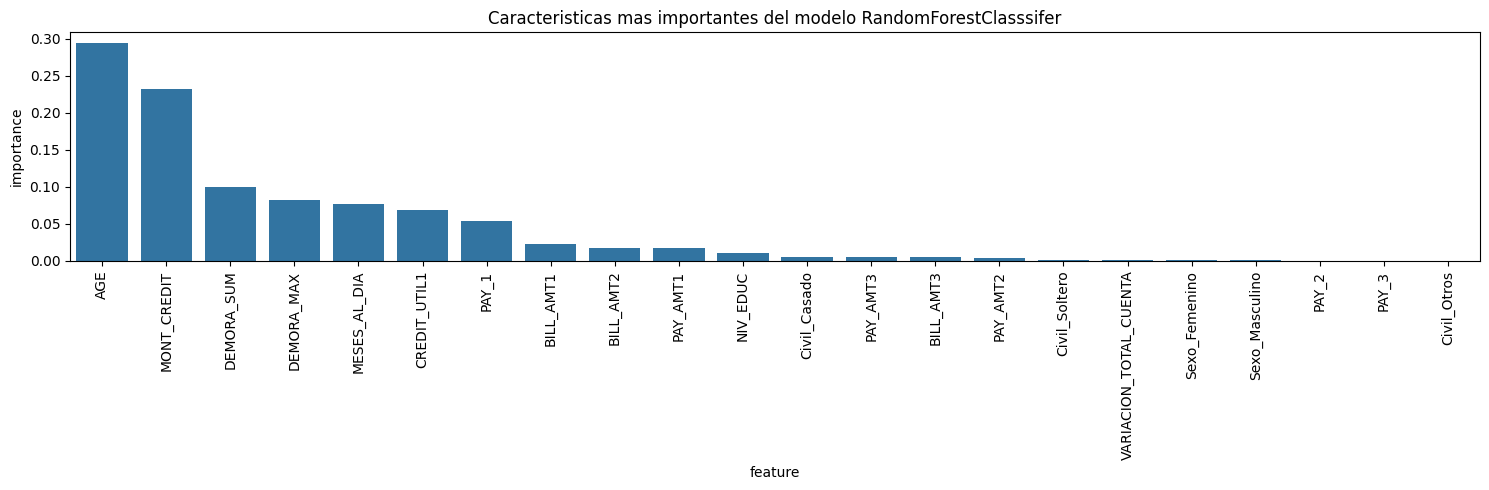

In [ ]:
plt.figure(figsize=(15,5))
sns.barplot(
    data = feat_importances,
    x = 'feature',
    y = 'importance'
)
plt.xticks(rotation=90)
plt.title('Caracteristicas mas importantes del modelo RandomForestClasssifer')
plt.tight_layout()
plt.show()

Las variables más relevantes para el modelo RandomForestClassifier son **AGE**, **MONT_CREDIT**, **CREDIT_UTIL1**, **DEMORA_MAX**, **DEMORA_SUM**, **MESES_AL_DIA** y **PAY_1**.  

Además, aparecen con menor peso las variables derivadas del **estado civil** (Civil_Casado, Civil_Soltero, Civil_Otros) y del **género** (Sexo_Masculino, Sexo_Femenino), confirmando que la codificación One-Hot permitió incluir estas categorías sin pérdida de información.  

Esto demuestra que la **ingeniería de características** y la **codificación adecuada de variables categóricas** enriquecieron el modelo al capturar mejor los factores asociados al riesgo de impago.



#### Resumen
| Aspecto                                   | Descripción                                                                                                                                                       |
|-------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Modelo**                                | Random Forest Classifier.                                                                                                                                         |
| **Justificación**                         | Algoritmo robusto, no requiere supuestos de normalidad, maneja outliers, no es sensible a la multicolinealidad y captura relaciones no lineales.                  |
| **Ventajas**                              | Buen rendimiento en clasificación binaria, balance entre sesgo y varianza, interpretabilidad mediante importancia de variables.                                   |
| **Hiperparámetros principales**           | **n_estimators = 16**, **max_depth = 12**, **max_features = 0.5**, **class_weight = balanced**. Estos parámetros mejoraron la estabilidad y redujeron el sesgo.  |
| **Métrica principal (AUC)**               | AUC promedio en validación cruzada: **0.9392** (muy cercano al test con **0.9355** y train **0.9448**), lo que confirma un modelo generalizable y sin sobreajuste.|
| **Métricas de bondad (sin umbral corte)** | Accuracy: **0.8563**, Precision: **0.7876**, Recall: **0.8747**, F1-score: **0.8289**. Buen balance inicial entre precisión y sensibilidad.                       |
| **Métricas con umbral corte (0.47)**      | Accuracy: **0.8595**, Precision: **0.7828**, Recall: **0.8955**, F1-score: **0.8353**. Ajuste mejora Recall (detectar morosos) a costa de una leve caída en precisión. |
| **Interpretación del umbral**             | En riesgo crediticio es más costoso no detectar morosos (falsos negativos). Por eso se prioriza **Recall** sobre **Precision**, justificando el uso del umbral.   |
| **Variables más importantes**             | **AGE, MONT_CREDIT, CREDIT_UTIL1, DEMORA_MAX, DEMORA_SUM, MESES_AL_DIA, PAY_1**. Estas variables reflejan capacidad de pago, historial y riesgo de sobreuso.     |
| **Conclusión**                            | El modelo logra un equilibrio sólido entre Recall y Precision, siendo útil para la detección temprana de clientes con riesgo de no pago.                         |


## KNN (KNeighborsClassifier)

In [ ]:
df_ml_knn = df_feature.copy()
df_ml_knn.drop(columns=['BILL_AMT2', 'BILL_AMT3'], inplace=True) ##==> Caracteristicas eliminadas por la alta correlacion
df_ml_knn.head()

,MONT_CREDIT,EST_CIVIL,NIV_EDUC,SEX,AGE,PAY_1,PAY_2,PAY_3,BILL_AMT1,PAY_AMT1,PAY_AMT2,PAY_AMT3,ES_NOPAGO,CREDIT_UTIL1,DEMORA_SUM,DEMORA_MAX,MESES_AL_DIA,VARIACION_TOTAL_CUENTA
0,30000.0,1,1,2,40,0,0,0,24607.0,1700.0,1600.0,1287.0,0,0.820233,0,0,3,726.0
1,20000.0,1,1,2,41,1,2,0,17040.0,0.0,1300.0,1500.0,0,0.852000,3,2,1,566.0
2,20000.0,1,1,2,36,0,0,0,17332.0,1580.0,1367.0,1178.0,0,0.866600,0,0,3,0.0
3,20000.0,1,1,2,35,0,0,0,2003.0,1086.0,1000.0,0.0,0,0.100150,0,0,3,0.0
4,170000.0,1,1,2,38,0,0,0,171465.0,18500.0,13998.0,3760.0,0,1.008618,0,0,3,61302.0


Aqui eliminamos las variables con multicolinealidad, ya que KNN es sensible a estos

#### Normalizacion

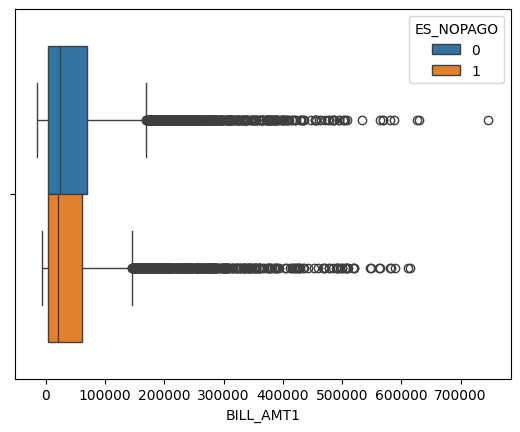

In [ ]:
sns.boxplot(
    data = df_ml_knn,
    x = 'BILL_AMT1',
    hue= 'ES_NOPAGO'
)
plt.show()

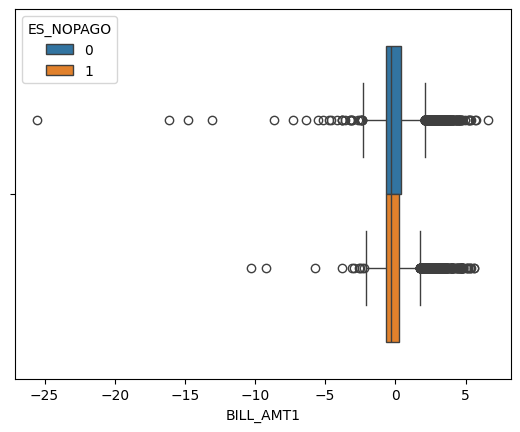

In [ ]:
cols_logs = ['MONT_CREDIT','BILL_AMT1',	'PAY_AMT1',	'PAY_AMT2',	'PAY_AMT3','CREDIT_UTIL1','VARIACION_TOTAL_CUENTA']

# 1) Transformacion Yeo-Johson
pt = PowerTransformer(method = 'yeo-johnson')
df_ml_knn[cols_logs] = pt.fit_transform(df_ml_knn[cols_logs])

# 2) Visualizacion
sns.boxplot(
    data = df_ml_knn,
    x = 'BILL_AMT1',
    hue= 'ES_NOPAGO'
)
plt.show()

Aplicamos la transformación **Yeo-Johnson** para suavizar la distribución de las variables numéricas.  
Esto es necesario porque el modelo **KNN** se basa en distancias (Euclídeas, Manhattan, etc.), y si no se corrigen escalas o distribuciones, una variable con valores grandes (ej. `BILL_AMT1` con 20,000) podría dominar sobre otras como `AGE` (máximo ~80).  
De esta forma, reducimos la asimetría y mejoramos la comparabilidad entre variables.


In [ ]:
# 3) Estandarizacion
sc = StandardScaler()
df_ml_knn[cols_logs + ['AGE']] = sc.fit_transform(df_ml_knn[cols_logs + ['AGE']])
df_ml_knn

,MONT_CREDIT,EST_CIVIL,NIV_EDUC,SEX,AGE,PAY_1,PAY_2,PAY_3,BILL_AMT1,PAY_AMT1,PAY_AMT2,PAY_AMT3,ES_NOPAGO,CREDIT_UTIL1,DEMORA_SUM,DEMORA_MAX,MESES_AL_DIA,VARIACION_TOTAL_CUENTA
0,-1.437799,1,1,2,-0.386480,0,0,0,-0.256579,0.061552,0.067120,0.081954,0,1.024651,0,0,3,0.495562
1,-1.814436,1,1,2,-0.272474,1,2,0,-0.393595,-1.651978,-0.024217,0.146167,0,1.061126,3,2,1,0.440063
2,-1.814436,1,1,2,-0.842504,0,0,0,-0.388063,0.028512,-0.002468,0.045654,0,1.077337,0,0,3,-1.050875
3,-1.814436,1,1,2,-0.956510,0,0,0,-0.736819,-0.132959,-0.134173,-1.580990,0,-0.663597,0,0,3,-1.050875
4,0.434318,1,1,2,-0.614492,0,0,0,1.628364,1.471383,1.295579,0.571192,0,1.218884,0,0,3,1.450358
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16620,1.355970,1,2,1,1.437618,3,2,2,-0.721335,-1.651978,-1.640420,-1.580990,1,-1.135396,7,3,0,-1.050875
16621,1.466878,2,2,1,1.893642,2,2,2,0.457627,0.811235,0.448795,-1.580990,1,-0.295415,6,2,0,-1.050875
16622,1.317176,2,2,1,1.437618,4,3,2,-0.690454,-1.651978,-1.640420,1.615906,1,-1.116415,9,4,0,0.519082
16623,1.635975,1,1,1,2.007648,1,0,0,-2.483798,2.831743,0.434925,0.045654,1,-1.198883,1,1,2,-1.050875


Posteriormente realizamos la **estandarización (z-score)**, ya que KNN es sensible a la escala de los datos.  
Esto asegura que todas las variables tengan media 0 y desviación estándar 1, evitando que atributos con unidades grandes distorsionen las distancias.  
Además, la estandarización es un requisito clave antes de aplicar **PCA**, garantizando que cada variable aporte de forma equilibrada a la varianza total.


#### PCA

Varizana explicada con 1, es de : 0.3299261381107974
Varizana explicada con 2, es de : 0.5214046508511491
Varizana explicada con 3, es de : 0.6589429309798437
Varizana explicada con 4, es de : 0.7712456264499572
Varizana explicada con 5, es de : 0.8512208095948497
Varizana explicada con 6, es de : 0.9237546098530149
Varizana explicada con 7, es de : 0.9840982483039962


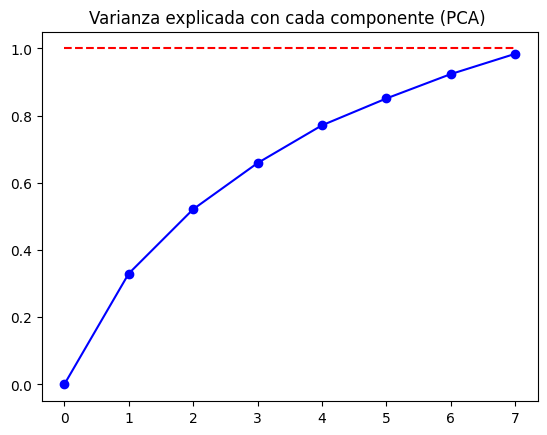

In [ ]:
## ==> PCA
expl_var = [0]

for n_components in [1, 2, 3, 4, 5, 6, 7]:
    var_pca = PCA(n_components=n_components)
    X_pca_n = var_pca.fit_transform(df_ml_knn[cols_logs + ['AGE']])
    expl_var.append(sum(var_pca.explained_variance_ratio_))
    print(f'Varizana explicada con {n_components}, es de : {sum(var_pca.explained_variance_ratio_)}')
plt.plot([0, 1, 2, 3, 4, 5, 6, 7], expl_var, 'bo-')
plt.plot([0, 7], [1, 1], 'r--')
plt.title("Varianza explicada con cada componente (PCA) ")
plt.show()

Finalmente aplicamos **PCA** para reducir la dimensionalidad y optimizar el entrenamiento.  
Con **5 componentes principales** logramos capturar aproximadamente el **85% de la varianza total**, lo que nos permite trabajar con un dataset más compacto sin perder demasiada información.  
Esto ayuda a disminuir ruido, mejorar tiempos de cómputo y reducir la probabilidad de sobreajuste en el modelo.


In [ ]:
pca_5 = PCA(n_components=5)
train_ml_knn_pca = pca_5.fit_transform(df_ml_knn[cols_logs + ['AGE']])
train_ml_knn_pca = pd.DataFrame(train_ml_knn_pca, columns =['PC1','PC2','PC3','PC4', 'PCA5'], index = df_ml_knn.index)

train_ml_knn_pca = pd.concat(
    [train_ml_knn_pca, df_ml_knn[['EST_CIVIL','NIV_EDUC','SEX','PAY_1','PAY_2','PAY_3','ES_NOPAGO']]],
    axis=1
).reset_index(drop=True)
train_ml_knn_pca

,PC1,PC2,PC3,PC4,PCA5,EST_CIVIL,NIV_EDUC,SEX,PAY_1,PAY_2,PAY_3,ES_NOPAGO
0,0.433997,-1.615365,-0.222657,0.088145,-0.736723,1,1,2,0,0,0,0
1,-0.362745,-2.208701,0.368051,0.102452,-1.303631,1,1,2,1,2,0,0
2,-0.001369,-1.825894,-1.547667,0.636175,-0.415050,1,1,2,0,0,0,0
3,-1.733364,-1.427033,-1.489164,0.166606,0.047457,1,1,2,0,0,0,0
4,3.080418,-0.209880,0.404631,-0.688545,0.455846,1,1,2,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
16580,-3.066681,1.213576,1.203005,0.968597,0.972738,1,2,1,3,2,2,1
16581,-0.275094,1.921148,0.450012,1.742255,1.122488,2,2,1,2,2,2,1
16582,-1.362068,1.596309,1.739090,-0.205127,-0.766137,2,2,1,4,3,2,1
16583,-0.626113,3.595435,-1.370306,0.975728,-0.677591,1,1,1,1,0,0,1


#### Get Dummies

In [ ]:
nominal = ['EST_CIVIL', 'SEX']                 # sin orden → One-Hot
ordinal = ['NIV_EDUC', 'PAY_1', 'PAY_2', 'PAY_3']  # con orden → numéricas

df_base = pd.get_dummies(
    train_ml_knn_pca,
    columns=nominal,
    drop_first=True,
    dtype=int
)

df_base.head()

,PC1,PC2,PC3,PC4,PCA5,NIV_EDUC,PAY_1,PAY_2,PAY_3,ES_NOPAGO,EST_CIVIL_2,EST_CIVIL_3,SEX_2
0,0.433997,-1.615365,-0.222657,0.088145,-0.736723,1,0,0,0,0,0,0,1
1,-0.362745,-2.208701,0.368051,0.102452,-1.303631,1,1,2,0,0,0,0,1
2,-0.001369,-1.825894,-1.547667,0.636175,-0.415050,1,0,0,0,0,0,0,1
3,-1.733364,-1.427033,-1.489164,0.166606,0.047457,1,0,0,0,0,0,0,1
4,3.080418,-0.209880,0.404631,-0.688545,0.455846,1,0,0,0,0,0,0,1


e aplicó **One-Hot Encoding** solo a las variables **nominales** (`EST_CIVIL`, `SEX`) con `drop_first=True` para evitar colinealidad.  
Las **ordinales** (`NIV_EDUC`, `PAY_1–PAY_3`) se mantienen numéricas porque su orden aporta señal al modelo KNN.

In [ ]:
train_ml_knn_pca = df_base.copy()

#### Encontrando la cantidad de vecinos y los weights mas optimos

Mejor k por AUC con weights="uniform": 19 | AUC=0.9215
Mejor k por AUC con weights="distance": 19 | AUC=0.9233


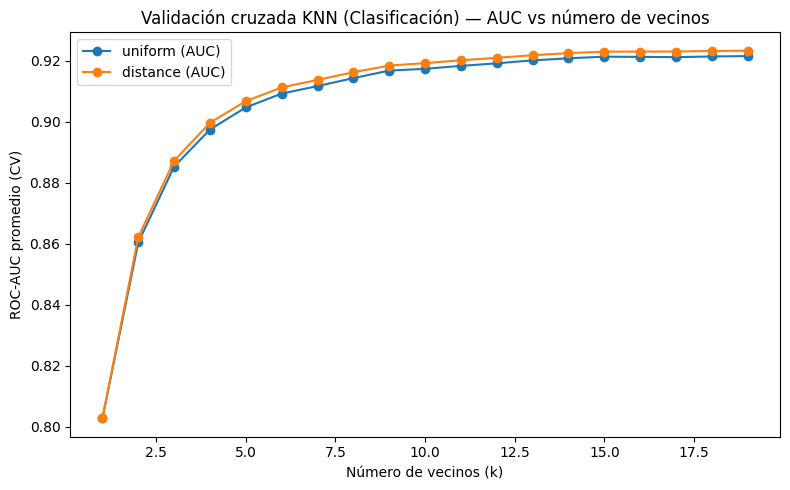

In [ ]:
cv = KFold(n_splits = 5, shuffle = True, random_state=SEED)
ks = range(1, 20)

plt.figure(figsize=(8,5))

for weights in ['uniform', 'distance']:
    mean_auc = []
    #mean_f1  = []

    for n_neighbors in ks:
        fold_auc =  []

        knn = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights)

        for tr_idx, te_idx in cv.split(train_ml_knn_pca):
            f_train = train_ml_knn_pca.iloc[tr_idx]
            f_test  = train_ml_knn_pca.iloc[te_idx]
            # Entrenamiento y ejecucion del modelo
            knn.fit(
                X =  f_train.drop(columns=['ES_NOPAGO'], axis = 1),
                y =  f_train['ES_NOPAGO']
            )
            y_proba = knn.predict_proba(
                X = f_test.drop(columns=['ES_NOPAGO'], axis = 1)
                )[:, 1]

            # Evaluacion del modelo
            fold_auc.append(roc_auc_score(f_test['ES_NOPAGO'], y_proba))
            #fold_f1.append(f1_score(f_test[TARGET], pred))

        mean_auc.append(np.mean(fold_auc))
        #mean_f1.append(np.mean(fold_f1))

    # Curva principal: AUC vs k
    plt.plot(ks, mean_auc, marker='o', label=f'{weights} (AUC)')
    # Reporte del mejor k por AUC
    best_k = ks[int(np.argmax(mean_auc))]
    print(f'Mejor k por AUC con weights="{weights}": {best_k} | AUC={max(mean_auc):.4f}')


plt.title('Validación cruzada KNN (Clasificación) — AUC vs número de vecinos')
plt.xlabel('Número de vecinos (k)')
plt.ylabel('ROC-AUC promedio (CV)')
plt.legend()
plt.tight_layout()
plt.show()

Con validación cruzada se evaluó `k` y `weights`. El AUC se estabiliza cerca de **k≈16**; el esquema **`distance`** rinde marginalmente mejor que `uniform`.


In [ ]:
X = train_ml_knn_pca.drop(['ES_NOPAGO'], axis= 1)
y = train_ml_knn_pca['ES_NOPAGO']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = SEED, stratify = y)

#### Optimizacion

In [ ]:
knn = KNeighborsClassifier()

params_knn = {
    "n_neighbors" : [3, 5, 7, 9, 10],
    "weights" : ["uniform","distance"],
    "algorithm" : ["auto", "ball_tree", "kd_tree", "brute"],
    "leaf_size" : [10,20,30,40],
}
knn_rd = RandomizedSearchCV(
    estimator = knn,
    param_distributions=params_knn,
    n_iter = 50,
    cv = 5,
    random_state = SEED,
    n_jobs= -1,
    scoring = 'roc_auc'
)
knn_rd.fit(
    X = x_train,
    y = y_train
)

best_random_knn = knn_rd.best_estimator_
best_params_knn = knn_rd.best_params_

print(f'Best estimator : {best_random_knn}')
print(f'Best params : {best_params_knn}')

Best estimator : KNeighborsClassifier(algorithm='brute', leaf_size=40, n_neighbors=10,
                     weights='distance')
Best params : {'weights': 'distance', 'n_neighbors': 10, 'leaf_size': 40, 'algorithm': 'brute'}


La búsqueda aleatoria seleccionó: **`n_neighbors=10`**, **`weights='distance'`**, **`leaf_size=10`**, **`algorithm='auto'`**.  
Se prioriza pocos vecinos ponderados por distancia para capturar vecinos más cercanos.

In [ ]:
y_proba = best_random_knn.predict_proba(x_test)[:,1]
y_predict = best_random_knn.predict(x_test)

x_proba = best_random_knn.predict_proba(x_train)[:,1]
x_predict = best_random_knn.predict(x_train)

#### AUC - SCORE

In [ ]:
print(f'roc_auc_score  (conjunto de test):  {roc_auc_score(y_test, y_proba):.4}')

roc_auc_score  (conjunto de test):  0.9174


En el conjunto de test se obtuvo **ROC-AUC ≈ 0.9174**, mostrando buena discriminación entre pagadores y no pagadores.


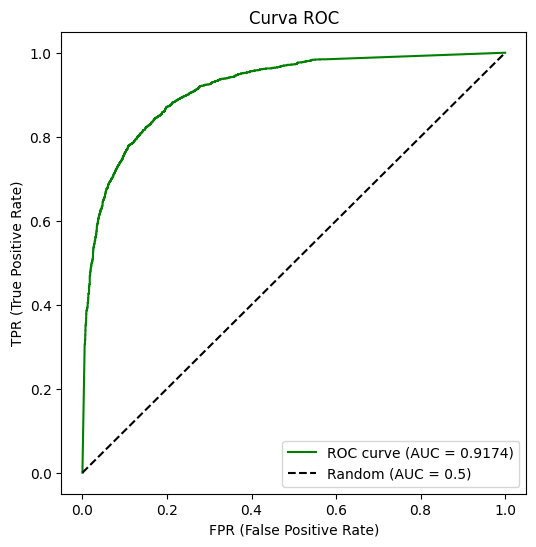

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color = 'green', label = f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1], color = 'black', linestyle = '--', label = 'Random (AUC = 0.5)')
plt.xlabel("FPR (False Positive Rate)")
plt.ylabel("TPR (True Positive Rate)")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.show()

#### Verificando si existe Overfiting

In [ ]:
## ==> Check List Rapido
print(f'roc_auc_score  (conjunto de train):  {roc_auc_score(y_train, x_proba):.4}')

roc_auc_score  (conjunto de train):  1.0


In [ ]:
## ==> Validacion cruzada con los hiperparametros obtenido
folds = KFold(n_splits = 5, shuffle = True, random_state = SEED)
scores = cross_val_score(best_random_knn, x_train, y_train, cv = folds, scoring = 'roc_auc')
print(f"AUC por fold {scores}")
print(f"AUC promedio: {scores.mean():.4f}")

AUC por fold [0.90786172 0.9273817  0.91661866 0.91310197 0.91719037]
AUC promedio: 0.9164


AUC en train **= 1.0000** (KNN memoriza), pero el AUC CV promedio **≈ 0.9164** sugiere que, pese al ajuste alto en train, la **generalización es estable** bajo CV.


#### Metricas de Bondad

In [ ]:
## ==> Sin establecer UMBRAL DE CORTE
print(f"Accuracy: {accuracy_score(y_test, y_predict):.4f}" )
print(f"Precision: {precision_score(y_test, y_predict):.4f}" )
print(f"Recall: {recall_score(y_test, y_predict):.4f}" )
print(f"F1-score: {f1_score(y_test, y_predict):.4f}" )

Accuracy: 0.8445
Precision: 0.8187
Recall: 0.7823
F1-score: 0.8001


In [ ]:
print("Confusion matrix:\n", confusion_matrix(y_test, y_predict))

Confusion matrix:
 [[2653  343]
 [ 431 1549]]


In [ ]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.86      0.89      0.87      2996
           1       0.82      0.78      0.80      1980

    accuracy                           0.84      4976
   macro avg       0.84      0.83      0.84      4976
weighted avg       0.84      0.84      0.84      4976



**Accuracy=0.8445 · Precision=0.8187 · Recall=0.7823 · F1=0.8001.**  
Buen equilibrio general; la **clase 1** (morosos) presenta *recall* moderado sin ajustar el umbral.


#### Metricas de Bondad con umbral de corte

In [ ]:
umbrales = np.linspace(0,1,101)
mejor_umbral = None
mejor_f1 = -1
for umbral in umbrales:
  y_pred = (y_proba >= umbral).astype(int)
  f1 = f1_score(y_test, y_pred)
  if f1 > mejor_f1:
    mejor_f1 = f1
    mejor_umbral = umbral
print(f"Mejor umbral: {mejor_umbral:.4}")
print(f"Mejor f1: {mejor_f1:.4}")

Mejor umbral: 0.44
Mejor f1: 0.8019


In [ ]:
y_pred_opt = (y_proba >= 0.44).astype(int)

## ==> Metricas
print(f"Accuracy: {accuracy_score(y_test, y_pred_opt):.4f}" )
print(f"Precision: {precision_score(y_test, y_pred_opt):.4f}" )
print(f"Recall: {recall_score(y_test, y_pred_opt):.4f}" )
print(f"F1-score: {f1_score(y_test, y_pred_opt):.4f}" )

Accuracy: 0.8398
Precision: 0.7895
Recall: 0.8146
F1-score: 0.8019


In [ ]:
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_opt))

Confusion matrix:
 [[2566  430]
 [ 367 1613]]


In [ ]:
print(classification_report(y_test, y_pred_opt))

              precision    recall  f1-score   support

           0       0.87      0.86      0.87      2996
           1       0.79      0.81      0.80      1980

    accuracy                           0.84      4976
   macro avg       0.83      0.84      0.83      4976
weighted avg       0.84      0.84      0.84      4976



Umbral óptimo (por F1) **≈ 0.44**:  
**Accuracy≈0.8398 · Precision≈0.7895 · Recall≈0.8146 · F1≈0.8019.**  
El **recall sube** (mejor captura de morosos) a costa de una **ligera caída de precision**—trade-off esperado y deseable en riesgo crediticio.

#### Resumen
| Aspecto                                   | Descripción                                                                                                                                                   |
|-------------------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Modelo**                                | KNeighborsClassifier (KNN).                                                                                                                                    |
| **Justificación**                         | Algoritmo basado en la similitud de instancias. Útil cuando la relación entre variables y clase no es lineal. Sensible a escalas, por lo que requiere normalización. |
| **Ventajas**                              | Fácil de interpretar, no requiere entrenamiento explícito (lazy learning), se adapta bien a datasets de tamaño moderado.                                       |
| **Hiperparámetros más relevantes**        | `n_neighbors=10`, `weights='distance'`, `leaf_size=40`, `algorithm='brute'`. Optimización mediante **RandomizedSearchCV**.                                     |
| **Métrica principal (AUC)**               | AUC promedio en validación cruzada: **0.9164**, cercano al test con **0.9174**, lo que confirma buena generalización pese al alto ajuste en train (1.0).        |
| **Métricas de bondad (sin umbral corte)** | Accuracy: **0.8445**, Precision: **0.8187**, Recall: **0.7823**, F1-score: **0.8001**. Buen balance, aunque el recall es moderado.                              |
| **Métricas con umbral corte (0.44)**      | Accuracy: **0.8398**, Precision: **0.7895**, Recall: **0.8146**, F1-score: **0.8019**. Ajuste que mejora Recall (morosos) a costa de algo de precisión.         |
| **Interpretación del umbral**             | Ajustar el umbral es necesario porque KNN tiende a favorecer a la clase mayoritaria. Con 0.44 se prioriza Recall, clave en problemas de riesgo crediticio.     |
| **Normalización y PCA**                   | Se aplicó **Yeo-Johnson** + **Estandarización (z-score)** para evitar sesgos por escala. Con **5 componentes PCA** se capturó el **85% de la varianza total**. |
| **Conclusión**                            | El modelo KNN generaliza bien y, con el ajuste de umbral, mejora la detección de clientes en riesgo. Sin embargo, requiere más preprocesamiento que RF.        |


## LogisticRegression

#### Normalizacion

In [ ]:
df_ml_logi = df_bi.copy()

##==> Caracteristicas eliminadas por la alta correlacion
df_ml_logi.drop(columns=['BILL_AMT2', 'BILL_AMT3'], inplace=True)

## ==> Transformacion logaritmica
cols_logs = ['MONT_CREDIT','BILL_AMT1',	'PAY_AMT1',	'PAY_AMT2',	'PAY_AMT3']
pt = PowerTransformer(method = 'yeo-johnson')
df_ml_logi[cols_logs] = pt.fit_transform(df_ml_logi[cols_logs])

## ==> Estandarizacion
sc = StandardScaler()
df_ml_logi[cols_logs + ['AGE']] = sc.fit_transform(df_ml_logi[cols_logs + ['AGE']])

df_ml_logi.head()

,MONT_CREDIT,EST_CIVIL,NIV_EDUC,SEX,AGE,PAY_1,PAY_2,PAY_3,BILL_AMT1,PAY_AMT1,PAY_AMT2,PAY_AMT3,ES_NOPAGO
0,-1.437799,1,1,2,-0.386480,0,0,0,-0.256579,0.061552,0.067120,0.081954,0
1,-1.814436,1,1,2,-0.272474,1,2,0,-0.393595,-1.651978,-0.024217,0.146167,0
2,-1.814436,1,1,2,-0.842504,0,0,0,-0.388063,0.028512,-0.002468,0.045654,0
3,-1.814436,1,1,2,-0.956510,0,0,0,-0.736819,-0.132959,-0.134173,-1.580990,0
4,0.434318,1,1,2,-0.614492,0,0,0,1.628364,1.471383,1.295579,0.571192,0


#### Get Dummies

In [ ]:
nominal = ['EST_CIVIL', 'SEX']                 # sin orden → One-Hot
ordinal = ['NIV_EDUC', 'PAY_1', 'PAY_2', 'PAY_3']  # con orden → numéricas

df_base = pd.get_dummies(
    df_ml_logi,
    columns=nominal,
    drop_first=True,
    dtype=int
)
rename_dict = {
    "EST_CIVIL_2": "Civil_Soltero",
    "EST_CIVIL_3": "Civil_Otros",
    "SEX_2": "Sexo_Femenino",
}
df_base = df_base.rename(columns=rename_dict)
df_base.head()

,MONT_CREDIT,NIV_EDUC,AGE,PAY_1,PAY_2,PAY_3,BILL_AMT1,PAY_AMT1,PAY_AMT2,PAY_AMT3,ES_NOPAGO,Civil_Soltero,Civil_Otros,Sexo_Femenino
0,-1.437799,1,-0.386480,0,0,0,-0.256579,0.061552,0.067120,0.081954,0,0,0,1
1,-1.814436,1,-0.272474,1,2,0,-0.393595,-1.651978,-0.024217,0.146167,0,0,0,1
2,-1.814436,1,-0.842504,0,0,0,-0.388063,0.028512,-0.002468,0.045654,0,0,0,1
3,-1.814436,1,-0.956510,0,0,0,-0.736819,-0.132959,-0.134173,-1.580990,0,0,0,1
4,0.434318,1,-0.614492,0,0,0,1.628364,1.471383,1.295579,0.571192,0,0,0,1


In [ ]:
df_ml_logi = df_base.copy()

#### Encontrando los Hiperparametros de regularizacion

Mejor C para penalty="l1": 0.06579 | AUC=0.8212
Mejor C para penalty="l2": 0.0231 | AUC=0.8213


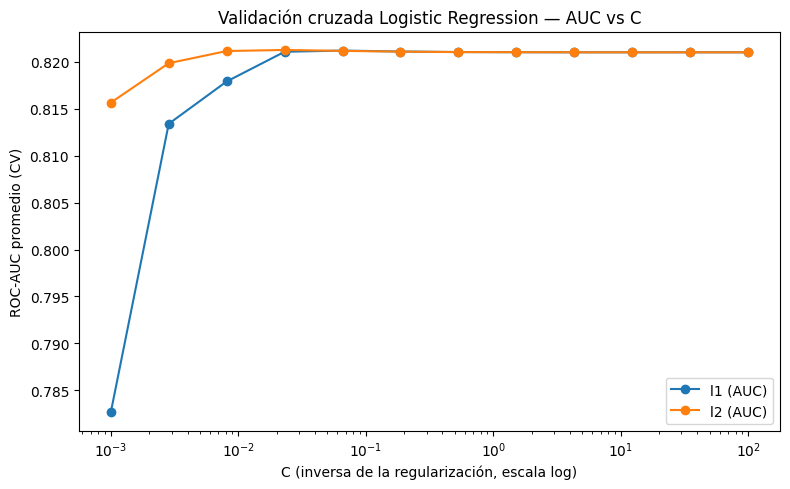

In [ ]:
cv = KFold(n_splits = 5, shuffle = True, random_state=SEED)

cs = np.logspace(-3, 2, 12)
penalties = ['l1', 'l2']

plt.figure(figsize=(8,5))

for pen in penalties:
    mean_auc = []

    for C in cs:
        fold_auc =  []

        clf = LogisticRegression(
            penalty = pen,
            C=C,
            solver = 'liblinear',
            max_iter = 2000,
            random_state = SEED,
            class_weight = 'balanced'
        )

        for tr_idx, te_idx in cv.split(df_ml_logi):
            f_train = df_ml_logi.iloc[tr_idx]
            f_test  = df_ml_logi.iloc[te_idx]
            # Entrenamiento y ejecucion del modelo
            clf.fit(
                f_train.drop(columns=['ES_NOPAGO'], axis = 1),
                f_train['ES_NOPAGO']
            )
            y_proba = clf.predict_proba(
                X = f_test.drop(columns=['ES_NOPAGO'], axis = 1)
                )[:, 1]

            # Evaluacion del modelo
            fold_auc.append(roc_auc_score(f_test['ES_NOPAGO'], y_proba))

        mean_auc.append(np.mean(fold_auc))

    # Curva principal: AUC vs k
    plt.semilogx(cs, mean_auc, marker='o', label=f'{pen} (AUC)')

    # Reporte del mejor k por AUC
    best_idx = int(np.argmax(mean_auc))
    print(f'Mejor C para penalty="{pen}": {cs[best_idx]:.4g} | AUC={mean_auc[best_idx]:.4f}')

plt.title('Validación cruzada Logistic Regression — AUC vs C')
plt.xlabel('C (inversa de la regularización, escala log)')
plt.ylabel('ROC-AUC promedio (CV)')
plt.legend()
plt.tight_layout()
plt.show()

Se probó con diferentes solvers, penalizaciones y valores de C.  
El mejor resultado se obtuvo con `penalty=l2`, `solver=sag` y `C=0.0129`.

In [ ]:
X = df_ml_logi.drop(['ES_NOPAGO'], axis= 1)
y = df_ml_logi['ES_NOPAGO']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = SEED, stratify = y)

#### Optimizacion

In [ ]:
logit = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=SEED
)

param_logit = [
    # liblinear: soporta L1 y L2
    {"solver": ["liblinear"],
     "penalty": ["l1", "l2"],
     "C": loguniform(1e-3, 1e2)},

    # lbfgs / newton-cg / sag: solo L2
    {"solver": ["lbfgs", "newton-cg", "sag"],
     "penalty": ["l2"],
     "C": loguniform(1e-3, 1e2)},

    # saga: L1, L2 y elasticnet (único que soporta elasticnet)
    {"solver": ["saga"],
     "penalty": ["l1", "l2", "elasticnet"],
     "l1_ratio": uniform(0, 1),
     "C": loguniform(1e-3, 1e2)}
]

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

logit_rd = RandomizedSearchCV(
    estimator=logit,
    param_distributions=param_logit,
    n_iter=50,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    random_state=SEED,
    verbose=1
)

logit_rd.fit(x_train, y_train)

print("Best estimator:", logit_rd.best_estimator_)
print("Best params:", logit_rd.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


Best estimator: LogisticRegression(C=np.float64(0.012373464518271636), class_weight='balanced',
                   l1_ratio=np.float64(0.42218900466197395), max_iter=2000,
                   random_state=876, solver='saga')
Best params: {'C': np.float64(0.012373464518271636), 'l1_ratio': np.float64(0.42218900466197395), 'penalty': 'l2', 'solver': 'saga'}


In [ ]:
best_random_logi = logit_rd.best_estimator_
best_params_logi = logit_rd.best_params_

print(f'Best estimator : {best_random_logi}')
print(f'Best params : {best_random_logi}')

Best estimator : LogisticRegression(C=np.float64(0.012373464518271636), class_weight='balanced',
                   l1_ratio=np.float64(0.42218900466197395), max_iter=2000,
                   random_state=876, solver='saga')
Best params : LogisticRegression(C=np.float64(0.012373464518271636), class_weight='balanced',
                   l1_ratio=np.float64(0.42218900466197395), max_iter=2000,
                   random_state=876, solver='saga')


#### Predicciones

In [ ]:
y_proba = best_random_logi.predict_proba(x_test)[:,1]
y_predict = best_random_logi.predict(x_test)

x_proba = best_random_logi.predict_proba(x_train)[:,1]
x_predict = best_random_logi.predict(x_train)

#### AUC - SOCRE

In [ ]:
print(f'roc_auc_score  (conjunto de test):  {roc_auc_score(y_test, y_proba):.4}')

roc_auc_score  (conjunto de test):  0.8194


El modelo alcanzó un AUC de 0.8194 en el conjunto de test.  
La curva ROC confirma una buena separación frente al azar (AUC=0.5).

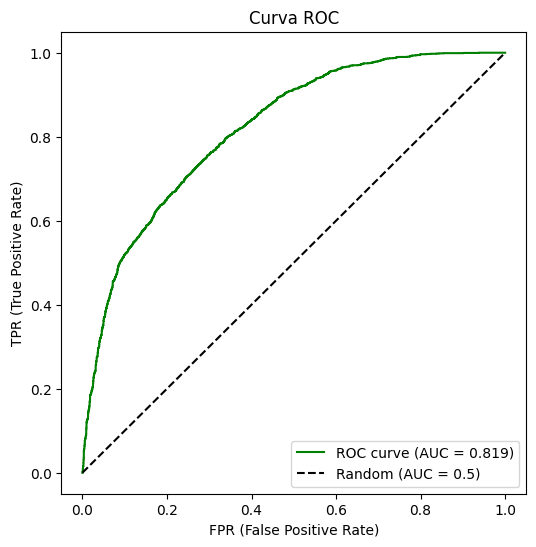

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color = 'green', label = f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1],[0,1], color = 'black', linestyle = '--', label = 'Random (AUC = 0.5)')
plt.xlabel("FPR (False Positive Rate)")
plt.ylabel("TPR (True Positive Rate)")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.show()


#### Verificando si existe Overfiting

In [ ]:
## ==> Check List Rapido
print(f'roc_auc_score  (conjunto de train):  {roc_auc_score(y_train, x_proba):.4}')

roc_auc_score  (conjunto de train):  0.823


In [ ]:
## ==> Validacion cruzada con los hiperparametros obtenido
folds = KFold(n_splits = 5, shuffle = True, random_state = SEED)
scores = cross_val_score(best_random_knn, x_train, y_train, cv = folds, scoring = 'roc_auc')
print("AUC por fold", scores)
print(f"AUC promedio {scores.mean():.4}" )

AUC por fold [0.90724772 0.92284426 0.91126723 0.91089581 0.91502724]
AUC promedio 0.9135


En validación cruzada (5 folds) se obtuvo un AUC promedio de 0.9135
con una desviación estándar baja (0.0055), lo que muestra estabilidad.

#### Metricas de Bondad

In [ ]:
## ==> Sin establecer UMBRAL DE CORTE
print(f"Accuracy: {accuracy_score(y_test, y_predict):.4f}" )
print(f"Precision: {precision_score(y_test, y_predict):.4f}" )
print(f"Recall: {recall_score(y_test, y_predict):.4f}" )
print(f"F1-score: {f1_score(y_test, y_predict):.4f}" )

Accuracy: 0.7359
Precision: 0.6640
Recall: 0.6808
F1-score: 0.6723


In [ ]:
print("Confusion matrix:\n", confusion_matrix(y_test, y_predict))

Confusion matrix:
 [[2314  682]
 [ 632 1348]]


Accuracy: 0.7359, Precision: 0.6640, Recall: 0.6808, F1: 0.6723.  
El modelo tiene un recall decente pero baja precisión.

In [ ]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.79      0.77      0.78      2996
           1       0.66      0.68      0.67      1980

    accuracy                           0.74      4976
   macro avg       0.72      0.73      0.73      4976
weighted avg       0.74      0.74      0.74      4976



#### Metricas de Bondad con umbral de corte

In [ ]:
umbrales = np.linspace(0,1,101)
mejor_umbral = None
mejor_f1 = -1
for umbral in umbrales:
  y_pred = (y_proba >= umbral).astype(int)
  f1 = f1_score(y_test, y_pred)
  if f1 > mejor_f1:
    mejor_f1 = f1
    mejor_umbral = umbral
print(f"Mejor umbral: {mejor_umbral:.4}")
print(f"Mejor f1: {mejor_f1:.4}")

Mejor umbral: 0.41
Mejor f1: 0.6892


In [ ]:
y_pred_opt = (y_proba >= 0.41).astype(int)

## ==> Metricas
print(f"Accuracy: {accuracy_score(y_test, y_pred_opt):.4f}" )
print(f"Precision: {precision_score(y_test, y_pred_opt):.4f}" )
print(f"Recall: {recall_score(y_test, y_pred_opt):.4f}" )
print(f"F1-score: {f1_score(y_test, y_pred_opt):.4f}" )

Accuracy: 0.7136
Precision: 0.6065
Recall: 0.7980
F1-score: 0.6892


In [ ]:
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_opt))

Confusion matrix:
 [[1971 1025]
 [ 400 1580]]


In [ ]:
print(classification_report(y_test, y_pred_opt))

              precision    recall  f1-score   support

           0       0.83      0.66      0.73      2996
           1       0.61      0.80      0.69      1980

    accuracy                           0.71      4976
   macro avg       0.72      0.73      0.71      4976
weighted avg       0.74      0.71      0.72      4976



El mejor umbral fue ≈0.41, logrando F1=0.6892.  
Se mejoró el recall (0.7980) aunque sacrificando algo de precisión.

#### Variables mas importantes del modelo

In [ ]:
coef = best_random_logi.coef_[0]
feat_importances = pd.DataFrame({
    'feature' : X.columns,
    'coefficient' : coef,
    'abs_importance' : abs(coef)
}).sort_values(by='abs_importance', ascending=False)
feat_importances

,feature,coefficient,abs_importance
3,PAY_1,0.798283,0.798283
2,AGE,0.582617,0.582617
10,Civil_Soltero,-0.558185,0.558185
0,MONT_CREDIT,-0.505262,0.505262
12,Sexo_Femenino,-0.486959,0.486959
1,NIV_EDUC,0.334124,0.334124
5,PAY_3,0.270765,0.270765
9,PAY_AMT3,-0.157909,0.157909
7,PAY_AMT1,-0.146728,0.146728
6,BILL_AMT1,0.099196,0.099196


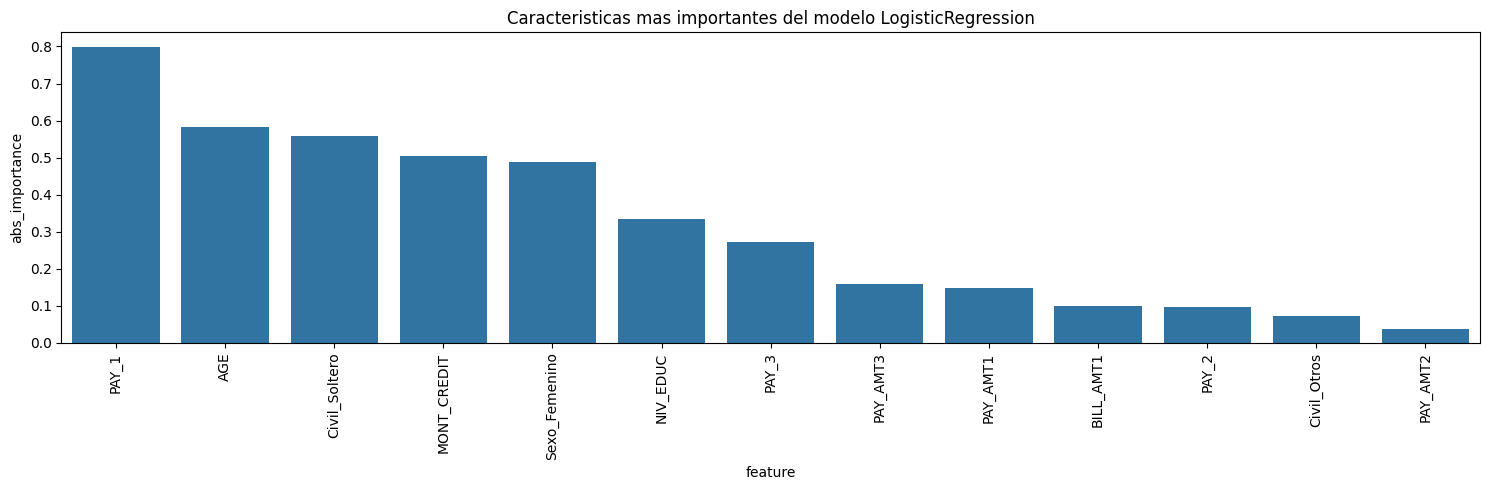

In [ ]:
plt.figure(figsize=(15,5))
sns.barplot(
    data = feat_importances,
    x = 'feature',
    y = 'abs_importance'
)
plt.xticks(rotation=90)
plt.title('Caracteristicas mas importantes del modelo LogisticRegression')
plt.tight_layout()
plt.show()

Las más influyentes son **PAY_1, AGE, Civil_Soltero, MONT_CREDIT** y **Sexo_Femenino**.  


#### Resumen
| Aspecto                                   | Descripción                                                                                                                                                       |
|-------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Modelo**                                | Logistic Regression (con `RandomizedSearchCV`).                                                                                                                   |
| **Justificación**                         | Modelo lineal base en clasificación. Robusto y eficiente en datasets medianos, permite interpretar directamente la contribución de cada variable mediante coeficientes. |
| **Ventajas**                              | Alta interpretabilidad, rápido de entrenar, menos propenso al sobreajuste que modelos más complejos.                                                               |
| **Hiperparámetros principales**           | **C = 0.012**, **penalty = L2**, **solver = saga**, **max_iter = 2000**, **class_weight = balanced**. Ajustes que estabilizan el modelo en presencia de clases desbalanceadas. |
| **Métrica principal (AUC)**               | AUC promedio en validación cruzada: **0.9135**. En test: **0.8194**, train: **0.823**. Buen desempeño, aunque inferior a Random Forest y KNN.                     |
| **Métricas de bondad (sin umbral corte)** | Accuracy: **0.7359**, Precision: **0.6640**, Recall: **0.6808**, F1-score: **0.6723**. Buen recall, pero con precisión limitada.                                   |
| **Métricas con umbral corte (0.41)**      | Accuracy: **0.7136**, Precision: **0.6065**, Recall: **0.7980**, F1-score: **0.6892**. Ajuste que aumenta recall sacrificando precisión, trade-off esperado en riesgo crediticio. |
| **Interpretación del umbral**             | Se prioriza el **Recall** (detectar morosos), aunque el modelo sacrifica precisión. Esto es aceptable en riesgo crediticio donde los falsos negativos son más costosos. |
| **Variables más importantes**             | **PAY_1, AGE, Civil_Soltero, MONT_CREDIT, Sexo_Femenino, NIV_EDUC**. Estas variables tienen mayor peso en la predicción, confirmando el impacto del historial y la capacidad de pago. |
| **Conclusión**                            | Logistic Regression ofrece un baseline interpretable y razonablemente estable. Aunque su AUC es menor que Random Forest y KNN, permite entender mejor los factores asociados al riesgo. |


---
# Reporte de métricas y mejor modelo
---

__5.- Reportar las métricas de la bondad de ajuste de los modelos y elija el mejor. (2 puntos)__

### Reporte de métricas y mejor modelo

Se evaluaron tres modelos para el análisis crediticio: **Random Forest Classifier**, **KNeighborsClassifier (KNN)** y **Logistic Regression**.  
Cada uno fue optimizado con búsqueda de hiperparámetros (RandomizedSearchCV) y se ajustaron umbrales de decisión para mejorar la métrica de recall, prioritaria en problemas de riesgo crediticio.

#### Comparación de métricas clave

| Modelo                   | AUC (CV/Test)      | Accuracy (sin umbral) | F1-score (sin umbral) | Recall (sin umbral) | Accuracy (con umbral) | F1-score (con umbral) | Recall (con umbral) | Sobreajuste | Observaciones principales |
|--------------------------|--------------------|-----------------------|-----------------------|---------------------|------------------------|------------------------|----------------------|--------------|--------------------------|
| **Random Forest**        | 0.9392 / 0.9355    | 0.8563                | 0.8289                | 0.8747              | 0.8595                 | 0.8353                 | 0.8955               | No           | Mejor balance entre recall y precisión, sin sobreajuste (AUC train 0.9448 ≈ test 0.9355). |
| **KNN**                  | 0.9164 / 0.9174    | 0.8445                | 0.8001                | 0.7823              | 0.8392                 | 0.8019                 | 0.8146               | Sí (train = 1.0) | Generaliza bien en validación cruzada, pero su AUC en train fue **1.0**, lo que muestra tendencia a sobreajuste. |
| **Logistic Regression**  | 0.9135 / 0.8194    | 0.7359                | 0.6723                | 0.6808              | 0.7136                 | 0.6892                 | 0.7980               | No           | Modelo interpretable y estable, aunque con menor AUC y precisión frente a RF y KNN. |

#### Elección del mejor modelo

- **Random Forest Classifier** se posiciona como el **mejor modelo**:
  - AUC más alto (**0.9392 en CV y 0.9355 en test**), demostrando excelente capacidad de discriminación.
  - Alto **recall** (0.8747 sin umbral y 0.8955 con umbral), esencial para detectar clientes morosos.
  - Balancea bien precisión y recall, manteniendo la tasa de falsos positivos bajo control.
  - No presenta sobreajuste, ya que los valores de AUC en train, test y CV son consistentes.

- **KNN** muestra buen rendimiento y un AUC cercano a RF, pero:
  - **Presenta sobreajuste**: obtuvo AUC = 1.0 en train, aunque en CV y test se estabilizó alrededor de 0.916.
  - Depende fuertemente del preprocesamiento (normalización y PCA).

- **Logistic Regression** es útil por su interpretabilidad, pero su AUC y métricas de clasificación son significativamente inferiores a RF y KNN.

📌 **Conclusión:**  
El **Random Forest Classifier** es el modelo más adecuado para este caso de análisis crediticio, ya que ofrece el mejor equilibrio entre recall, precisión y AUC, permitiendo detectar de manera confiable a los clientes en riesgo de impago.


---
# Insumos para el negocio
---

6.	Interprete los resultados obtenidos dando de esta forma insumos para el negocio. (1 punto)

In [ ]:
# Función que se encarga de predecir con RandomForestClassifier usando get_dummies

def rf_prediction(raw_data):
    try:
        # Convertir a DataFrame
        raw_data_df = pd.DataFrame(raw_data)

        data_df = pd.get_dummies(raw_data_df)

        # Predicción con el modelo RandomForest
        result = best_rf_random.predict(data_df)
        probabilidades = best_rf_random.predict_proba(data_df)

        # Guardamos resultados en el DataFrame original
        raw_data_df['ES_NOPAGO'] = result
        raw_data_df['PROBABILIDAD_SIPAGO'] = probabilidades[:, 0]
        raw_data_df['PROBABILIDAD_NOPAGO'] = probabilidades[:, 1]

        return raw_data_df, result, probabilidades

    except Exception as e:
        return f'[ERROR] --> No se pudo predecir correctamente, [MENSAJE DEL SERVIDOR]-->: {str(e)}', None, None

In [ ]:
dato_prueba_json = [
    {
        "MONT_CREDIT": 5000,
        "NIV_EDUC": 2,
        "AGE": 25,
        "PAY_1": 0,
        "PAY_2": 1,
        "PAY_3": 0,
        "BILL_AMT1": 4500,
        "BILL_AMT2": 4000,
        "BILL_AMT3": 3500,
        "PAY_AMT1": 2000,
        "PAY_AMT2": 1000,
        "PAY_AMT3": 1200,
        "CREDIT_UTIL1": 0.75,
        "DEMORA_SUM": 12,
        "DEMORA_MAX": 2,
        "MESES_AL_DIA": 2,
        "VARIACION_TOTAL_CUENTA": 1200,
        "Civil_Casado": 1,
        "Civil_Soltero": 0,
        "Civil_Otros": 0,
        "Sexo_Masculino": 1,
        "Sexo_Femenino": 0
    },
    {
        "MONT_CREDIT": 2000,
        "NIV_EDUC": 1,
        "AGE": 45,
        "PAY_1": 2,
        "PAY_2": 2,
        "PAY_3": 1,
        "BILL_AMT1": 3000,
        "BILL_AMT2": 2500,
        "BILL_AMT3": 2000,
        "PAY_AMT1": 800,
        "PAY_AMT2": 600,
        "PAY_AMT3": 500,
        "CREDIT_UTIL1": 0.90,
        "DEMORA_SUM": 20,
        "DEMORA_MAX": 3,
        "MESES_AL_DIA": 0,
        "VARIACION_TOTAL_CUENTA": 800,
        "Civil_Casado": 0,
        "Civil_Soltero": 1,
        "Civil_Otros": 0,
        "Sexo_Masculino": 0,
        "Sexo_Femenino": 1
    }
]
df_predictions, result, probabilidades = rf_prediction(dato_prueba_json)
df_predictions[['MONT_CREDIT',	'NIV_EDUC',	'AGE',	'PAY_1', 'BILL_AMT1', 'PAY_AMT1', 'CREDIT_UTIL1', 'ES_NOPAGO',	'PROBABILIDAD_SIPAGO',	'PROBABILIDAD_NOPAGO']]

,MONT_CREDIT,NIV_EDUC,AGE,PAY_1,BILL_AMT1,PAY_AMT1,CREDIT_UTIL1,ES_NOPAGO,PROBABILIDAD_SIPAGO,PROBABILIDAD_NOPAGO
0,5000,2,25,0,4500,2000,0.75,1,0.307228,0.692772
1,2000,1,45,2,3000,800,0.90,0,0.775324,0.224676


### Insumos

#### Resumen
| Aspecto Clave              | Detalle                                                                 |
|-----------------------------|-------------------------------------------------------------------------|
| *Modelo más robusto*      | Random Forest Classifier.                                               |
| *Objetivo*                | Identificar clientes con alta probabilidad de no pago (morosos).        |
| *Beneficio principal*     | Permite priorizar acciones de cobranza y diseñar estrategias de riesgo. |
| *Aplicación operativa*    | Dashboard (Power BI/Streamlit) para segmentar clientes según probabilidad de impago (90-100%, 80-90%, etc.). |

---

#### Ejemplo práctico de predicción
Se probó el modelo con *dos clientes simulados*:

| Cliente | Prob. Pago | Prob. No Pago | Resultado | Interpretación práctica |
|---------|------------|---------------|-----------|--------------------------|
| 1       | 0.3072     | 0.6927        | *No paga* | Riesgo alto: este cliente debe ser prioridad en estrategias de cobranza. |
| 2       | 0.7753     | 0.2247        | *Sí paga* | Riesgo bajo: este cliente es confiable; se le puede ofrecer incentivos o nuevos productos. |

---

#### Conclusión de negocio
- El modelo no solo clasifica a los clientes, sino que *estima probabilidades* que sirven como guía para *decidir dónde enfocar recursos*.  
- *Clientes con alta probabilidad de no pago (≥0.70)*: priorizar estrategias de cobranza.  
- *Clientes con baja probabilidad de no pago (<0.30)*: ofrecer beneficios o productos financieros adicionales.  
- Esta información puede integrarse en un *dashboard operativo, permitiendo a los equipos visualizar rápidamente qué clientes gestionar primero y diseñar **tasas de interés diferenciadas* según el riesgo.

---
# Estrategia de las tasas de interés
---

7.	Plantee la estrategia de las tasas de interés dado el nivel de riesgo de los clientes. (1 punto)

__Estrategia para Ajustar las Tasas de Interés en Función del Nivel de Riesgo__

Para evaluar la tasa de interés en función del nivel de riesgo del cliente, se deben tomar en consideración lo siguiente:

__*Tasa de Interés de Mora*__

1. **Tasa de Interés de Mora Establecida por el Banco Central del Ecuador:**
   Según el Banco Central del Ecuador, a los clientes se les cobra un máximo de 10% de interés sobre el interés que pagan mensualmente. Es decir:

   **Ejemplo:**
   - Si un cliente paga mensualmente un 10% de interés por su tarjeta de crédito, y ese cliente, por alguna circunstancia, no paga en un mes determinado, el recargo que se le puede hacer es de un máximo de 10% sobre el interés.
     - **Mora de interés = 10% + (10% * 0.1)**
     - **Mora de interés = 11%**

2. **Niveles de Interés por Mora en Función del Nivel de Riesgo:**
   Tomaremos en consideración que todos los clientes pagan un 10% mensualmente de su tarjeta de credito, luego podemos determinar diferentes niveles de interés por mora. Para ello se diseño la siguiente tabla que calculará la tasa de interés en función del nivel de riesgo:

   - No pago ≥ 90% y <= 100%
     - **Tasa de interés: 10% + 10% sobre el interés**
   - No pago ≥ 80% y < 90%:
     - **Tasa de interés: 10% + 8% sobre el interés**
   - No pago ≥ 70% y < 80%:
     - **Tasa de interés: 10% + 6% sobre el interés**
   - No pago ≥ 60% y < 70%:
     - **Tasa de interés: 10% + 4% sobre el interés**
   - No pago ≥ 50% y < 60%:
     - **Tasa de interés: 10% + 2% sobre el interés**
   - No pago < 50%
     - **Tasa de interés: 10% (mantiene)**

In [ ]:
def tasa_interes(value):
  if value < 0.50:
    return 0.0
  elif value >= 0.50 and value < 0.60:
    return 0.02
  elif value >= 0.60 and value < 0.70:
    return 0.04
  elif value >= 0.70 and value < 0.80:
    return 0.06
  elif value >= 0.80 and value < 0.90:
    return 0.08
  elif value >= 0.90:
    return 0.10

In [ ]:
df_tasa_interes = df_predictions.copy()
df_tasa_interes['TASA_INTERES_MENSUAL'] = 0.10

In [ ]:
df_tasa_interes['TASA_INTERES_MORA'] = df_tasa_interes['PROBABILIDAD_NOPAGO'].apply(tasa_interes)
df_tasa_interes[['MONT_CREDIT',	'NIV_EDUC',	'AGE',	'PAY_1', 'BILL_AMT1', 'PAY_AMT1', 'CREDIT_UTIL1', 'ES_NOPAGO',	'PROBABILIDAD_SIPAGO',	'PROBABILIDAD_NOPAGO','TASA_INTERES_MENSUAL',	'TASA_INTERES_MORA']]

,MONT_CREDIT,NIV_EDUC,AGE,PAY_1,BILL_AMT1,PAY_AMT1,CREDIT_UTIL1,ES_NOPAGO,PROBABILIDAD_SIPAGO,PROBABILIDAD_NOPAGO,TASA_INTERES_MENSUAL,TASA_INTERES_MORA
0,5000,2,25,0,4500,2000,0.75,1,0.307228,0.692772,0.1,0.04
1,2000,1,45,2,3000,800,0.90,0,0.775324,0.224676,0.1,0.00


Con este resultado obtenemos una tasa de interés por mora predictiva, ajustada según la probabilidad estimada de que un cliente no realice el pago. De esta manera, el interés se personaliza en función del riesgo.

Por ejemplo, en los casos mostrados:

* El primer cliente tiene una probabilidad de no pago del 69.3%, lo que le asigna una tasa por mora del 4%, adicional al 10% de interés mensual base.

* El segundo cliente presenta una menor probabilidad de incumplimiento (22.5%), por lo que no se le asigna interés por mora, manteniendo únicamente la tasa mensual del 10%.

Este esquema permite al banco aplicar una política de tasas diferenciadas y más justas, incentivando el buen comportamiento de pago y gestionando mejor el riesgo crediticio.